# ClearRead — Rhetorical Analysis & Fallacy Detection

## NLP Model Application and Analysis

**Author:** Solo developer  
**Course:** AI 400 — Final Project  
**Date:** March 2026  

---

### Project Overview

ClearRead is a browser extension that helps users think critically about what they read online. When a user highlights text on any webpage — news articles, tweets, blog posts — the extension analyzes it for **logical fallacies and manipulative rhetorical techniques**, then provides soft, educational explanations.

This notebook documents the **NLP model development pipeline** behind ClearRead:

1. **Data Preparation** — Downloading, mapping, and splitting labeled fallacy datasets
2. **V1 Model Training** — Fine-tuning DistilRoBERTa on 10 fallacy categories
3. **Evaluation & Error Analysis** — Per-class metrics, confusion matrices, misclassification patterns
4. **ONNX Export & Quantization** — Converting to ONNX + INT8 for in-browser inference
5. **Claim Detector** — Binary classifier to filter neutral text before fallacy classification
6. **V2 Model (LLM Distillation)** — Expanding to 41 categories using LLM-generated training data
7. **V3 Model (DeBERTa Experiment)** — Testing a larger base model
8. **Cross-Model LLM Benchmark** — Comparing local model vs. 12 cloud/local LLMs
9. **Discussion & Future Improvements**

### Model Architecture

| Component | Model | Parameters | Task |
|-----------|-------|------------|------|
| Claim Detector | MiniLM-L12-H384 | 33M | Binary: claim vs. neutral |
| Fallacy Classifier (V1) | DistilRoBERTa-base | 82M | 10-class fallacy classification |
| Fallacy Classifier (V2) | DistilRoBERTa-base | 82M | 41-class fallacy classification |
| Fallacy Classifier (V3) | DeBERTa-v3-large | 304M | 41-class fallacy classification |

### Inference Pipeline

```
Input Text → Sentence Splitting → Claim Detector (filter neutral) → Fallacy Classifier → Results
```

The extension also supports **LLM-based remote inference** (Ollama, OpenAI, Anthropic, Google Gemini) as an alternative engine, which is benchmarked against the local model in Section 8.

---
## Environment Setup

Import all required libraries for data analysis, visualization, and model evaluation.

In [2]:
%pip install numpy pandas matplotlib seaborn pyyaml scikit-learn

  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Image, HTML, Markdown

# Set plot style for consistent, clean visualizations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Base directory — all paths relative to the model/ folder
BASE_DIR = Path(".").resolve()
if BASE_DIR.name != "model":
    # If notebook is run from a different working directory, adjust
    if (BASE_DIR / "model").exists():
        BASE_DIR = BASE_DIR / "model"

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {BASE_DIR / 'data' / 'processed'}")
print(f"Output directory: {BASE_DIR / 'output'}")

Base directory: D:\Repos\clear-read\model
Data directory: D:\Repos\clear-read\model\data\processed
Output directory: D:\Repos\clear-read\model\output


---
## 1. Data Preparation

### 1.1 Data Sources

Two primary datasets were used:

| Dataset | Source | Examples | Use |
|---------|--------|----------|-----|
| **Logical Fallacy Detection** | [HuggingFace: tasksource/logical-fallacy](https://huggingface.co/datasets/tasksource/logical-fallacy) | 3,761 | Primary training data — direct fallacy labels |
| **Propaganda Techniques Corpus** | [SemEval 2020 Task 11](https://propaganda.qcri.org/) | Supplementary | Propaganda techniques mapped to fallacy categories |

### 1.2 Label Mapping

Both datasets use different taxonomies. The `prepare_data.py` script consolidates them into a **10-category taxonomy** for V1:

| Source Label (examples) | → Target Label |
|------------------------|----------------|
| `faulty generalization` | `hasty_generalization` |
| `ad populum` | `appeal_to_popular_opinion` |
| `false causality` | `post_hoc` |
| `false dilemma` | `false_dichotomy` |
| `fallacy of extension` | `straw_man` |
| `Name_Calling,Labeling` (Propaganda) | `ad_hominem` |
| `Black-and-White_Fallacy` (Propaganda) | `false_dichotomy` |

### 1.3 Data Exploration

Let's load and examine the prepared training data.

In [4]:
# ─── Load V1 data splits ─────────────────────────────────────────────
data_dir = BASE_DIR / "data" / "processed"

with open(data_dir / "train.json", encoding="utf-8") as f:
    train_data = json.load(f)
with open(data_dir / "val.json", encoding="utf-8") as f:
    val_data = json.load(f)
with open(data_dir / "test.json", encoding="utf-8") as f:
    test_data = json.load(f)
with open(data_dir / "label_map.json", encoding="utf-8") as f:
    label_map = json.load(f)

# Reverse mapping: id → label name
id_to_label = {v: k for k, v in label_map.items()}
label_names = [id_to_label[i] for i in range(len(id_to_label))]

print("=== V1 Dataset Statistics ===")
print(f"Training examples:    {len(train_data):,}")
print(f"Validation examples:  {len(val_data):,}")
print(f"Test examples:        {len(test_data):,}")
print(f"Total:                {len(train_data) + len(val_data) + len(test_data):,}")
print(f"Number of classes:    {len(label_map)}")
print(f"\nLabel mapping: {json.dumps(label_map, indent=2)}")

=== V1 Dataset Statistics ===
Training examples:    2,573
Validation examples:  322
Test examples:        322
Total:                3,217
Number of classes:    10

Label mapping: {
  "straw_man": 0,
  "begging_the_question": 1,
  "ad_hominem": 2,
  "post_hoc": 3,
  "false_dichotomy": 4,
  "equivocation": 5,
  "appeal_to_authority": 6,
  "hasty_generalization": 7,
  "appeal_to_popular_opinion": 8,
  "red_herring": 9
}


=== Label Distribution ===


,Label,Train,Validation,Test,Total,Train %
0,hasty_generalization,441,55,55,551,17.1
1,equivocation,389,48,49,486,15.1
2,begging_the_question,309,39,39,387,12.0
3,ad_hominem,302,38,38,378,11.7
4,appeal_to_popular_opinion,229,29,28,286,8.9
5,post_hoc,220,27,28,275,8.6
6,appeal_to_authority,195,25,24,244,7.6
7,red_herring,193,24,24,241,7.5
8,straw_man,149,19,18,186,5.8
9,false_dichotomy,146,18,19,183,5.7


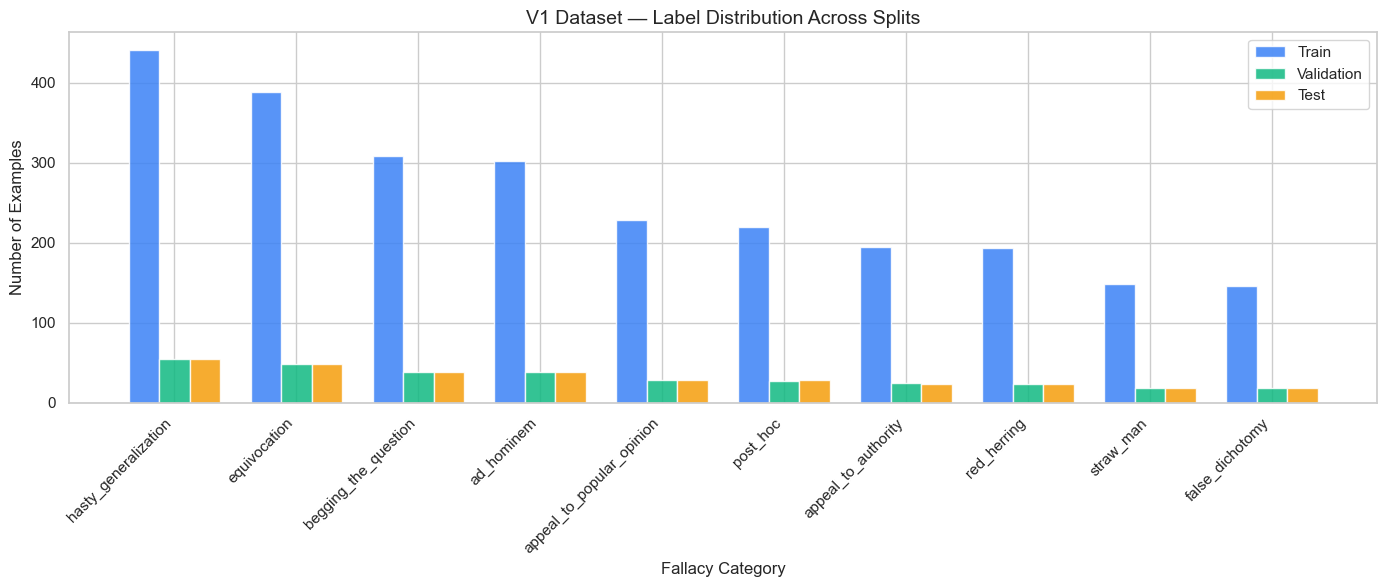

In [5]:
# ─── Label distribution across splits ─────────────────────────────────
def count_labels(data, label_names):
    """Count occurrences of each label in a data split."""
    counter = Counter(ex["label"] for ex in data)
    return [counter.get(label, 0) for label in label_names]

train_counts = count_labels(train_data, label_names)
val_counts = count_labels(val_data, label_names)
test_counts = count_labels(test_data, label_names)

# Create a DataFrame for clean display
dist_df = pd.DataFrame({
    "Label": label_names,
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts,
    "Total": [t + v + te for t, v, te in zip(train_counts, val_counts, test_counts)],
})
dist_df["Train %"] = (dist_df["Train"] / dist_df["Train"].sum() * 100).round(1)
dist_df = dist_df.sort_values("Total", ascending=False).reset_index(drop=True)

print("=== Label Distribution ===")
display(dist_df)

# ─── Visualization: label distribution bar chart ──────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names))
width = 0.25

sorted_labels = dist_df["Label"].tolist()
sorted_train = dist_df["Train"].tolist()
sorted_val = dist_df["Validation"].tolist()
sorted_test = dist_df["Test"].tolist()

ax.bar(x - width, sorted_train, width, label="Train", color="#3b82f6", alpha=0.85)
ax.bar(x, sorted_val, width, label="Validation", color="#10b981", alpha=0.85)
ax.bar(x + width, sorted_test, width, label="Test", color="#f59e0b", alpha=0.85)

ax.set_xlabel("Fallacy Category")
ax.set_ylabel("Number of Examples")
ax.set_title("V1 Dataset — Label Distribution Across Splits")
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

=== Sample Examples (one per category) ===

[ad_hominem]
  "Well , not a debate … because climate alarmists who were invited didn ’ t show ."

[equivocation]
  "Don't be out-dated and un-fashionable! Buy the new, modern double-lined heavy duty jeans - the old ripped jeans of the past are out!"

[hasty_generalization]
  ""Flight attendants are the nicest people. I should know—I’ve taken two flights.""

[red_herring]
  "So many people are speaking up about animal rights, but what they should first focus on is human rights."

[straw_man]
  "Teacher: You are receiving a zero because you didn't do your homework.

Students: Are you serious? You gave me a zero because you hate me????"

[appeal_to_authority]
  "News flash , Mr. President : Alaska has been buffeted by cyclical swings in climate for thousands of years ."

[false_dichotomy]
  "Either you text your friend or you don't have any fun at all."

[begging_the_question]
  "“Guns are like hammers—they’re both tools with metal parts that c

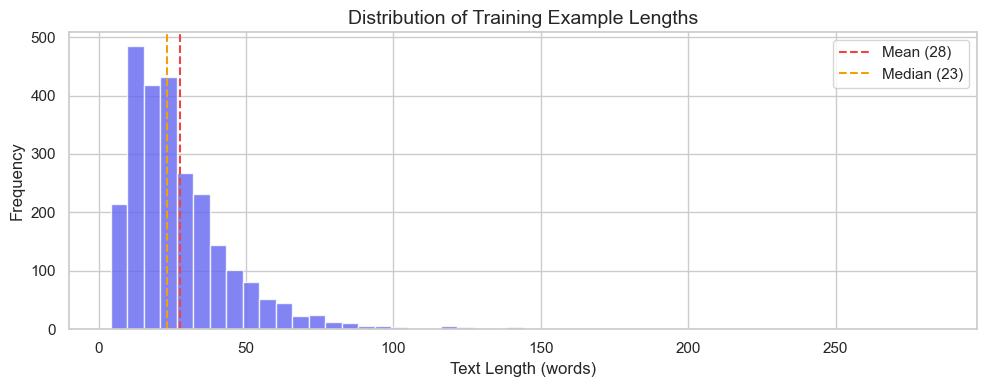

In [6]:
# ─── Sample examples from each category ───────────────────────────────
print("=== Sample Examples (one per category) ===")
print()

seen_labels = set()
for ex in train_data:
    if ex["label"] not in seen_labels:
        seen_labels.add(ex["label"])
        # Truncate long texts for display
        text = ex["text"][:200] + "..." if len(ex["text"]) > 200 else ex["text"]
        print(f"[{ex['label']}]")
        print(f"  \"{text}\"")
        print()
    if len(seen_labels) == len(label_map):
        break

# ─── Text length statistics ───────────────────────────────────────────
train_lengths = [len(ex["text"].split()) for ex in train_data]
print(f"\n=== Text Length Statistics (word count) ===")
print(f"Mean:   {np.mean(train_lengths):.1f} words")
print(f"Median: {np.median(train_lengths):.1f} words")
print(f"Min:    {np.min(train_lengths)} words")
print(f"Max:    {np.max(train_lengths)} words")
print(f"Std:    {np.std(train_lengths):.1f} words")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_lengths, bins=50, color="#6366f1", alpha=0.8, edgecolor="white")
ax.axvline(np.mean(train_lengths), color="#ef4444", linestyle="--", label=f"Mean ({np.mean(train_lengths):.0f})")
ax.axvline(np.median(train_lengths), color="#f59e0b", linestyle="--", label=f"Median ({np.median(train_lengths):.0f})")
ax.set_xlabel("Text Length (words)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Training Example Lengths")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. V1 Model — Fine-tuning DistilRoBERTa

### 2.1 Model Selection Rationale

**DistilRoBERTa-base** (82M parameters) was chosen as the base model for several reasons:

1. **Good accuracy-to-size ratio** — Distilled from RoBERTa, retains ~95% of its performance at 60% of the size
2. **ONNX compatibility** — Well-supported by Transformers.js and ONNX Runtime for in-browser inference
3. **Quantization-friendly** — INT8 quantization reduces the model from ~328MB to ~79MB with minimal accuracy loss
4. **Strong NLU baseline** — RoBERTa's improved pretraining (dynamic masking, larger batches) gives better text understanding than BERT

### 2.2 Training Configuration

The training uses the HuggingFace `Trainer` API with early stopping.

In [7]:
# ─── Display V1 training configuration ────────────────────────────────
import yaml

config_path = BASE_DIR / "configs" / "training_config.yaml"
with open(config_path, encoding="utf-8") as f:
    v1_config = yaml.safe_load(f)

print("=== V1 Training Configuration ===")
config_df = pd.DataFrame([
    {"Parameter": k, "Value": str(v)}
    for k, v in v1_config.items()
    if k != "label_names"  # skip the long label list for display
])
display(config_df)

print(f"\nLabel names ({len(v1_config['label_names'])}): {v1_config['label_names']}")

=== V1 Training Configuration ===


,Parameter,Value
0,model_name,distilroberta-base
1,num_labels,10
2,max_length,256
3,batch_size,16
4,learning_rate,2e-5
5,epochs,5
6,warmup_ratio,0.1
7,weight_decay,0.01
8,evaluation_strategy,epoch
9,metric_for_best_model,f1_macro



Label names (10): ['straw_man', 'begging_the_question', 'ad_hominem', 'post_hoc', 'false_dichotomy', 'equivocation', 'appeal_to_authority', 'hasty_generalization', 'appeal_to_popular_opinion', 'red_herring']


In [8]:
# ─── Training code (reference — already executed via train.py) ─────────
#
# The training was run using: python scripts/train.py
#
# Key steps in the training pipeline:
#   1. Load train/val JSON data and label map
#   2. Tokenize with AutoTokenizer (max_length=256, padding, truncation)
#   3. Initialize DistilRoBERTa with num_labels=10 classification head
#   4. Train with HuggingFace Trainer:
#      - EarlyStoppingCallback(patience=2) based on val F1
#      - Learning rate: 2e-5 with linear warmup (10% of steps)
#      - Weight decay: 0.01
#      - Evaluation after each epoch
#   5. Save best model checkpoint
#
# Below shows the core training function for reference:

training_code = '''
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# Load pre-trained model with classification head
model_name = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=10,
    id2label=id_to_label,
    label2id=label_map,
)

# Tokenize datasets
def tokenize_dataset(data, tokenizer, label_map, max_length):
    texts = [ex["text"] for ex in data]
    labels = [label_map[ex["label"]] for ex in data]
    encodings = tokenizer(
        texts, truncation=True, padding="max_length",
        max_length=max_length, return_tensors="np",
    )
    dataset = Dataset.from_dict({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": labels,
    })
    dataset.set_format("torch")
    return dataset

# Training arguments
training_args = TrainingArguments(
    output_dir="output/checkpoints",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
)

# Compute metrics callback
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "accuracy": accuracy_score(labels, predictions),
    }

# Train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer.train()
trainer.save_model("output/best_model")
'''
print(training_code)


from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# Load pre-trained model with classification head
model_name = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=10,
    id2label=id_to_label,
    label2id=label_map,
)

# Tokenize datasets
def tokenize_dataset(data, tokenizer, label_map, max_length):
    texts = [ex["text"] for ex in data]
    labels = [label_map[ex["label"]] for ex in data]
    encodings = tokenizer(
        texts, truncation=True, padding="max_length",
        max_length=max_length, return_tensors="np",
    )
    dataset = Dataset.from_dict({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": labels,
    })
    dataset.set_format("torch")
    return dataset

# Training arguments
trainin

In [9]:
# ─── V1 Training Results ─────────────────────────────────────────────
# Load the saved training metrics from the completed training run

with open(BASE_DIR / "output" / "training_metrics.json", encoding="utf-8") as f:
    v1_metrics = json.load(f)

print("=== V1 Training Results (Best Checkpoint) ===")
metrics_df = pd.DataFrame([
    {"Metric": "Validation Loss", "Value": f"{v1_metrics['eval_loss']:.4f}"},
    {"Metric": "Accuracy", "Value": f"{v1_metrics['eval_accuracy']:.4f} ({v1_metrics['eval_accuracy']*100:.1f}%)"},
    {"Metric": "Macro F1", "Value": f"{v1_metrics['eval_f1_macro']:.4f} ({v1_metrics['eval_f1_macro']*100:.1f}%)"},
    {"Metric": "Epochs", "Value": f"{v1_metrics['eval_epoch'] if 'eval_epoch' in v1_metrics else v1_metrics.get('epoch', 'N/A')}"},
    {"Metric": "Inference Speed", "Value": f"{v1_metrics['eval_samples_per_second']:.1f} samples/sec"},
])
display(metrics_df)

=== V1 Training Results (Best Checkpoint) ===


,Metric,Value
0,Validation Loss,1.5173
1,Accuracy,0.5466 (54.7%)
2,Macro F1,0.5323 (53.2%)
3,Epochs,5.0
4,Inference Speed,296.7 samples/sec


---
## 3. V1 Model Evaluation

### 3.1 Classification Report

The model was evaluated on the held-out test set (322 examples) using the standard classification metrics: **Precision**, **Recall**, and **F1-score** per class, plus overall accuracy.

In [10]:
# ─── Load V1 classification report from evaluation ────────────────────
eval_dir = BASE_DIR / "output" / "evaluation"

with open(eval_dir / "classification_report.json", encoding="utf-8") as f:
    v1_report = json.load(f)

# Build a per-class metrics table
class_rows = []
for label in label_names:
    if label in v1_report:
        r = v1_report[label]
        class_rows.append({
            "Fallacy": label,
            "Precision": f"{r['precision']:.3f}",
            "Recall": f"{r['recall']:.3f}",
            "F1-Score": f"{r['f1-score']:.3f}",
            "Support": int(r['support']),
        })

# Add summary rows
for avg_type in ["macro avg", "weighted avg"]:
    if avg_type in v1_report:
        r = v1_report[avg_type]
        class_rows.append({
            "Fallacy": f"— {avg_type} —",
            "Precision": f"{r['precision']:.3f}",
            "Recall": f"{r['recall']:.3f}",
            "F1-Score": f"{r['f1-score']:.3f}",
            "Support": int(r['support']),
        })

report_df = pd.DataFrame(class_rows)
print(f"=== V1 Classification Report (Test Set — {int(v1_report.get('accuracy', 0) * 322)} / 322 correct) ===")
print(f"Overall Accuracy: {v1_report['accuracy']:.4f} ({v1_report['accuracy']*100:.1f}%)")
print()
display(report_df)

=== V1 Classification Report (Test Set — 174 / 322 correct) ===
Overall Accuracy: 0.5404 (54.0%)



,Fallacy,Precision,Recall,F1-Score,Support
0,straw_man,0.556,0.556,0.556,18
1,begging_the_question,0.429,0.385,0.405,39
2,ad_hominem,0.639,0.605,0.622,38
3,post_hoc,0.667,0.571,0.615,28
4,false_dichotomy,0.684,0.684,0.684,19
5,equivocation,0.411,0.469,0.438,49
6,appeal_to_authority,0.500,0.417,0.455,24
7,hasty_generalization,0.542,0.709,0.614,55
8,appeal_to_popular_opinion,0.700,0.500,0.583,28
9,red_herring,0.500,0.458,0.478,24


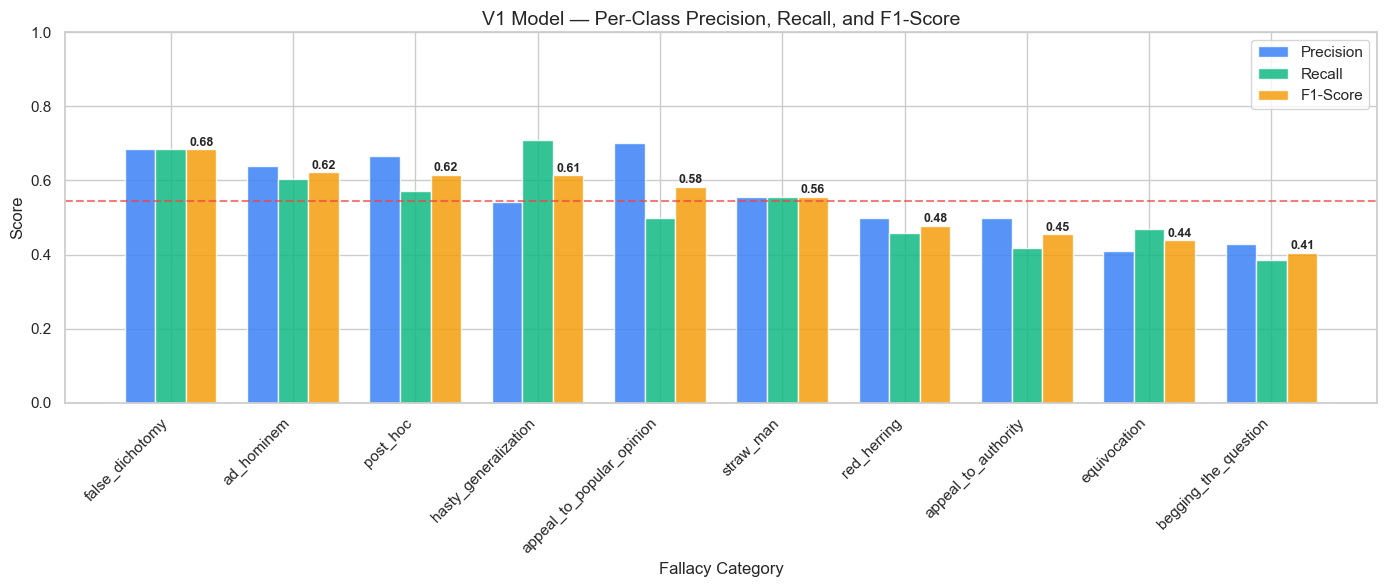

In [11]:
# ─── Per-class F1 visualization ──────────────────────────────────────
f1_scores = []
precisions = []
recalls = []
plot_labels = []

for label in label_names:
    if label in v1_report:
        f1_scores.append(v1_report[label]["f1-score"])
        precisions.append(v1_report[label]["precision"])
        recalls.append(v1_report[label]["recall"])
        plot_labels.append(label)

# Sort by F1 score descending
sorted_idx = np.argsort(f1_scores)[::-1]
plot_labels = [plot_labels[i] for i in sorted_idx]
f1_scores = [f1_scores[i] for i in sorted_idx]
precisions = [precisions[i] for i in sorted_idx]
recalls = [recalls[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_labels))
width = 0.25

ax.bar(x - width, precisions, width, label="Precision", color="#3b82f6", alpha=0.85)
ax.bar(x, recalls, width, label="Recall", color="#10b981", alpha=0.85)
ax.bar(x + width, f1_scores, width, label="F1-Score", color="#f59e0b", alpha=0.85)

# Add F1 value labels on top of bars
for i, f1 in enumerate(f1_scores):
    ax.text(i + width, f1 + 0.01, f"{f1:.2f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Fallacy Category")
ax.set_ylabel("Score")
ax.set_title("V1 Model — Per-Class Precision, Recall, and F1-Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=45, ha="right")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.axhline(y=v1_report["macro avg"]["f1-score"], color="#ef4444", linestyle="--", alpha=0.7, label="Macro Avg F1")
plt.tight_layout()
plt.show()

### 3.2 Confusion Matrix

The confusion matrix reveals which fallacy types the model most commonly confuses with each other.

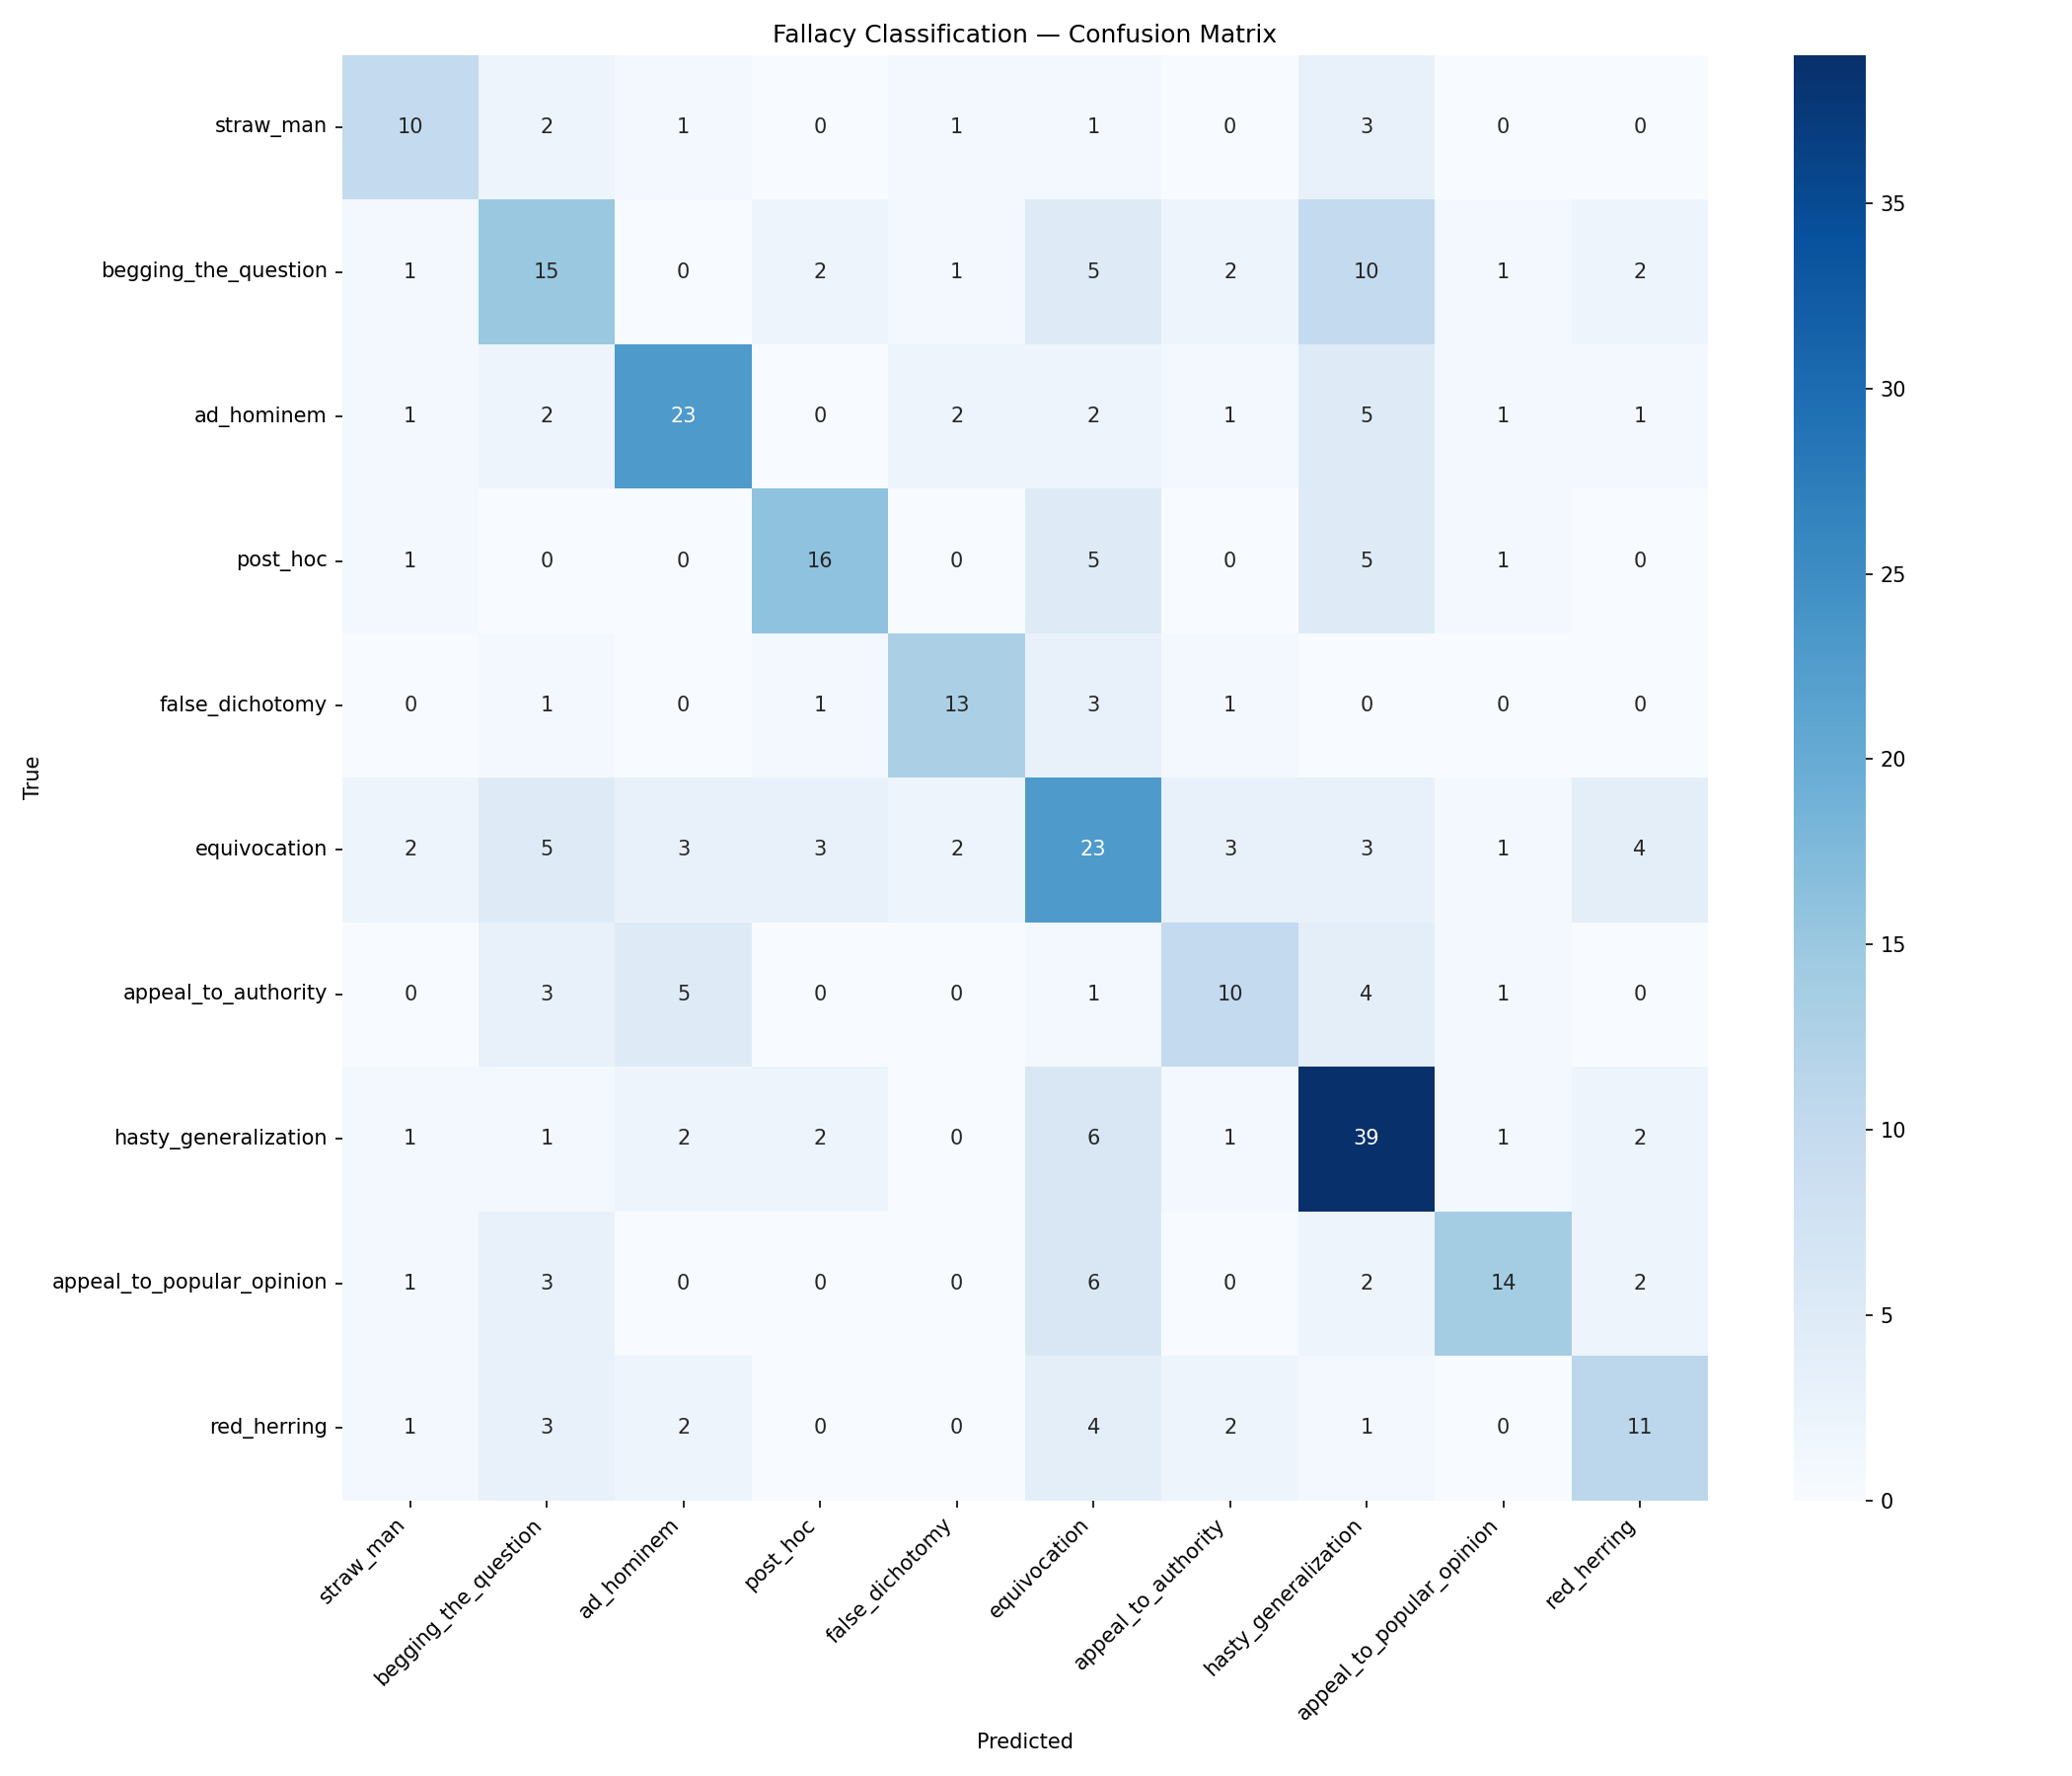

In [12]:
# ─── Display the saved confusion matrix ───────────────────────────────
confusion_path = eval_dir / "confusion_matrix.png"

if confusion_path.exists():
    display(Image(filename=str(confusion_path), width=700))
else:
    print("Confusion matrix image not found. Run evaluate.py to generate it.")

### 3.3 Error Analysis

Examining misclassified examples reveals patterns the model struggles with — particularly where fallacy categories have overlapping linguistic features.

In [13]:
# ─── Error analysis — misclassification patterns ──────────────────────
with open(eval_dir / "error_analysis.json", encoding="utf-8") as f:
    errors = json.load(f)

print(f"=== Error Analysis ===")
print(f"Total misclassified: {len(errors)} / 322 ({len(errors)/322*100:.1f}%)")
print()

# Confusion pairs — which pairs of labels are most commonly confused?
confusion_pairs = Counter()
for err in errors:
    pair = (err["true_label"], err["predicted_label"])
    confusion_pairs[pair] += 1

print("Most common confusion pairs (true → predicted):")
for (true_label, pred_label), count in confusion_pairs.most_common(10):
    print(f"  {true_label:30s} → {pred_label:30s} ({count} times)")

# Show a few specific misclassified examples
print("\n=== Sample Misclassified Examples ===")
for err in errors[:5]:
    text = err["text"][:200] + "..." if len(err["text"]) > 200 else err["text"]
    print(f"\n  True: {err['true_label']:25s}  Predicted: {err['predicted_label']}")
    print(f"  \"{text}\"")

=== Error Analysis ===
Total misclassified: 148 / 322 (46.0%)

Most common confusion pairs (true → predicted):
  begging_the_question           → hasty_generalization           (10 times)
  hasty_generalization           → equivocation                   (6 times)
  appeal_to_popular_opinion      → equivocation                   (6 times)
  post_hoc                       → equivocation                   (5 times)
  appeal_to_authority            → ad_hominem                     (5 times)
  post_hoc                       → hasty_generalization           (5 times)
  ad_hominem                     → hasty_generalization           (5 times)
  equivocation                   → begging_the_question           (5 times)
  begging_the_question           → equivocation                   (5 times)
  appeal_to_authority            → hasty_generalization           (4 times)

=== Sample Misclassified Examples ===

  True: hasty_generalization       Predicted: equivocation
  "Global sea level rose perm

### 3.4 Key Observations — V1 Model

**Strengths:**
- `false_dichotomy` (F1: 0.68) and `ad_hominem` (F1: 0.62) are the best-performing classes — these have distinctive linguistic markers ("either...or", personal attacks)
- `hasty_generalization` achieves good recall (0.71), suggesting the model catches sweeping language patterns

**Weaknesses:**
- `begging_the_question` (F1: 0.41) and `equivocation` (F1: 0.44) are the weakest — these are semantically subtle and require deeper reasoning
- `equivocation` is frequently confused with other categories because word-sense ambiguity is hard to detect from surface patterns
- Class imbalance: `equivocation` has the most examples (49 in test) while others have far fewer

**Overall:** 54% accuracy / 54.5% macro F1 across 10 fine-grained categories. This is a challenging task — random baseline would be ~10%, and human inter-annotator agreement on fallacy detection is typically 50-70%.

---
## 4. ONNX Export & Quantization

For deployment in a browser extension, the PyTorch model must be converted to **ONNX format** and quantized to reduce file size.

### 4.1 Export Process

The `export_onnx.py` script performs three steps:

1. **ONNX Export** — Convert PyTorch model to ONNX computational graph using HuggingFace Optimum
2. **INT8 Dynamic Quantization** — Reduce model weights from FP32 to INT8 (4x size reduction)
3. **Parity Validation** — Verify that the quantized model produces the same predictions as the original

In [14]:
# ─── ONNX export code (reference — already executed via export_onnx.py) ──

export_code = '''
from optimum.exporters.onnx import main_export
from optimum.onnxruntime import ORTQuantizer
from optimum.onnxruntime.configuration import AutoQuantizationConfig

# Step 1: Export PyTorch model to ONNX
main_export(
    model_name_or_path="output/best_model",
    output="output/onnx",
    task="text-classification",
)

# Step 2: Apply INT8 dynamic quantization
quantizer = ORTQuantizer.from_pretrained("output/onnx")
qconfig = AutoQuantizationConfig.avx512_vnni(is_static=False, per_channel=False)
quantizer.quantize(save_dir="output/onnx_quantized", quantization_config=qconfig)

# Step 3: Validate output parity (compare predictions on test texts)
'''
print(export_code)

# ─── Report model sizes ───────────────────────────────────────────────
def get_dir_size(path):
    """Calculate total size of all files in a directory (in bytes)."""
    total = 0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total

sizes = {}
for name, subdir in [("V1 Best Model", "output/best_model"),
                      ("V1 ONNX (FP32)", "output/onnx"),
                      ("V1 ONNX (INT8 Quantized)", "output/onnx_quantized"),
                      ("V2 ONNX (INT8 Quantized)", "output_v2/onnx_quantized")]:
    p = BASE_DIR / subdir
    if p.exists():
        size_mb = get_dir_size(p) / 1e6
        sizes[name] = size_mb
        print(f"{name:35s}: {size_mb:7.1f} MB")

if sizes:
    print(f"\nQuantization compression ratio: {sizes.get('V1 Best Model', 0) / sizes.get('V1 ONNX (INT8 Quantized)', 1):.1f}x")


from optimum.exporters.onnx import main_export
from optimum.onnxruntime import ORTQuantizer
from optimum.onnxruntime.configuration import AutoQuantizationConfig

# Step 1: Export PyTorch model to ONNX
main_export(
    model_name_or_path="output/best_model",
    output="output/onnx",
    task="text-classification",
)

# Step 2: Apply INT8 dynamic quantization
quantizer = ORTQuantizer.from_pretrained("output/onnx")
qconfig = AutoQuantizationConfig.avx512_vnni(is_static=False, per_channel=False)
quantizer.quantize(save_dir="output/onnx_quantized", quantization_config=qconfig)

# Step 3: Validate output parity (compare predictions on test texts)

V1 Best Model                      :   333.3 MB
V1 ONNX (FP32)                     :   333.4 MB
V1 ONNX (INT8 Quantized)           :    87.4 MB
V2 ONNX (INT8 Quantized)           :    87.4 MB

Quantization compression ratio: 3.8x


### 4.2 Browser Integration

The quantized ONNX model (~79 MB) is bundled into the Chrome extension under `extension/public/model/`. At runtime, **Transformers.js** (a JavaScript port of the HuggingFace Transformers library) loads the model using **ONNX Runtime Web** (WebAssembly backend) and runs inference entirely client-side — no data leaves the user's browser.

```
extension/public/model/
├── config.json              # Model architecture configuration
├── tokenizer.json           # Tokenizer vocabulary
├── tokenizer_config.json    # Tokenizer settings
├── vocab.json               # RoBERTa vocabulary
├── merges.txt               # BPE merges
└── onnx/
    └── model_quantized.onnx # INT8 quantized ONNX model (~79 MB)
```

---
## 5. Claim Detector — Filtering Neutral Text

### 5.1 Motivation

In real-world text (news articles, social media), only a fraction of sentences make argumentative claims — the rest are neutral reporting, quotes, or factual statements. Running every sentence through the fallacy classifier wastes compute and increases false positives.

The **Claim Detector** is a lightweight binary classifier that runs _before_ the fallacy classifier to filter out neutral sentences.

### 5.2 Architecture

| Property | Value |
|----------|-------|
| Base model | `microsoft/MiniLM-L12-H384-uncased` (33M params) |
| Task | Binary classification: `claim` vs. `neutral` |
| Training data | LLM-generated examples via `generate_claim_data.py` |
| ONNX size | ~12 MB (INT8 quantized) |

In [15]:
# ─── Claim Detector Results ───────────────────────────────────────────
claim_metrics_path = BASE_DIR / "output_claim_detector" / "training_metrics.json"

with open(claim_metrics_path, encoding="utf-8") as f:
    claim_metrics = json.load(f)

print("=== Claim Detector — Validation Results ===")
val_m = claim_metrics["validation"]
print(f"Accuracy:    {val_m['eval_accuracy']:.4f} ({val_m['eval_accuracy']*100:.1f}%)")
print(f"Macro F1:    {val_m['eval_f1_macro']:.4f}")
print(f"Precision:   {val_m['eval_precision']:.4f}")
print(f"Recall:      {val_m['eval_recall']:.4f}")

print("\n=== Claim Detector — Test Results ===")
test_m = claim_metrics["test"]
print(f"Accuracy:    {test_m['accuracy']:.4f} ({test_m['accuracy']*100:.1f}%)")
print(f"Macro F1:    {test_m['macro_f1']:.4f}")
print(f"ROC AUC:     {test_m['roc_auc']:.4f}")

print("\nPer-class metrics:")
for cls, metrics in test_m["per_class"].items():
    print(f"  {cls:10s}: Precision={metrics['precision']:.3f}  Recall={metrics['recall']:.3f}  F1={metrics['f1-score']:.3f}  Support={int(metrics['support'])}")

=== Claim Detector — Validation Results ===
Accuracy:    1.0000 (100.0%)
Macro F1:    1.0000
Precision:   1.0000
Recall:      1.0000

=== Claim Detector — Test Results ===
Accuracy:    0.9899 (99.0%)
Macro F1:    0.9899
ROC AUC:     1.0000

Per-class metrics:
  claim     : Precision=1.000  Recall=0.980  F1=0.990  Support=49
  neutral   : Precision=0.980  Recall=1.000  F1=0.990  Support=50



Training & Validation Loss:


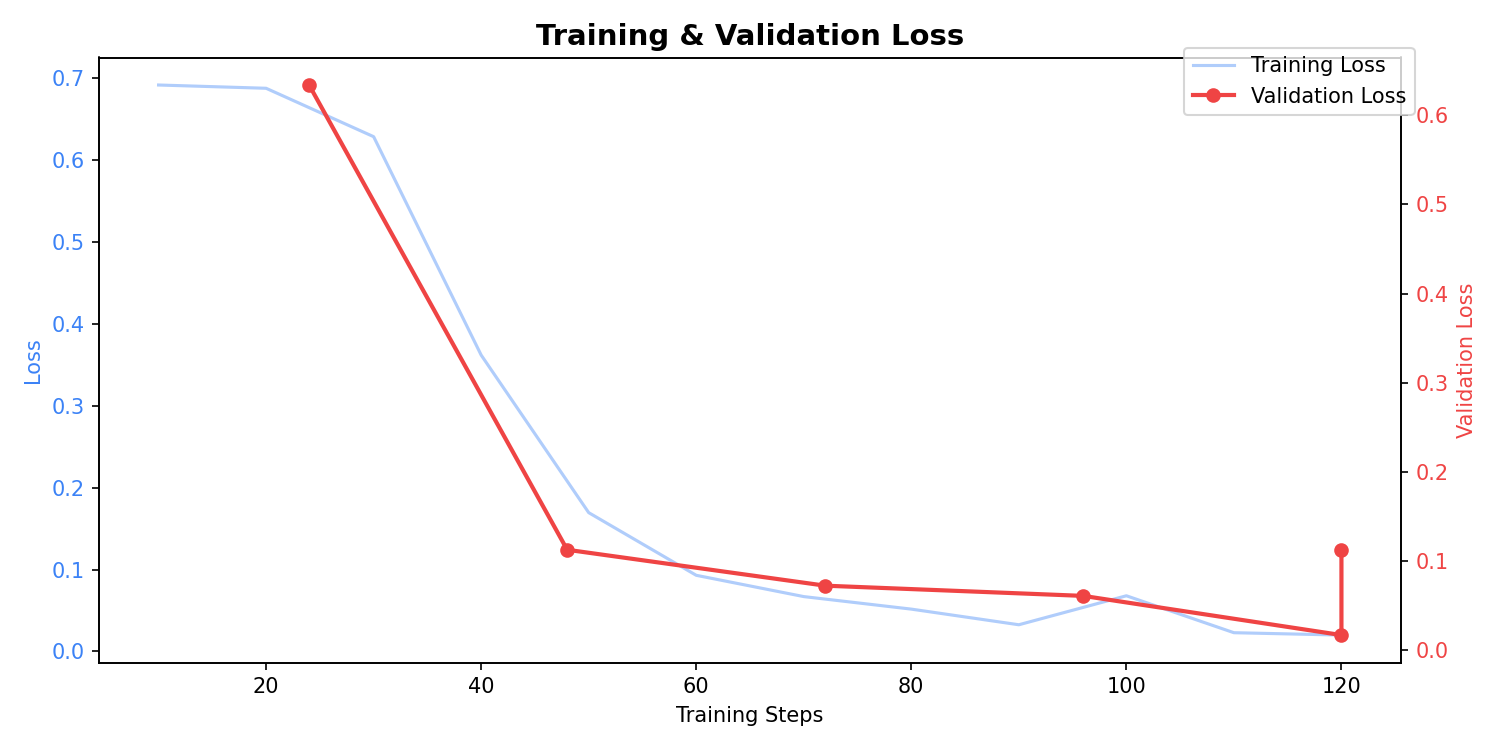


Validation Metrics Per Epoch:


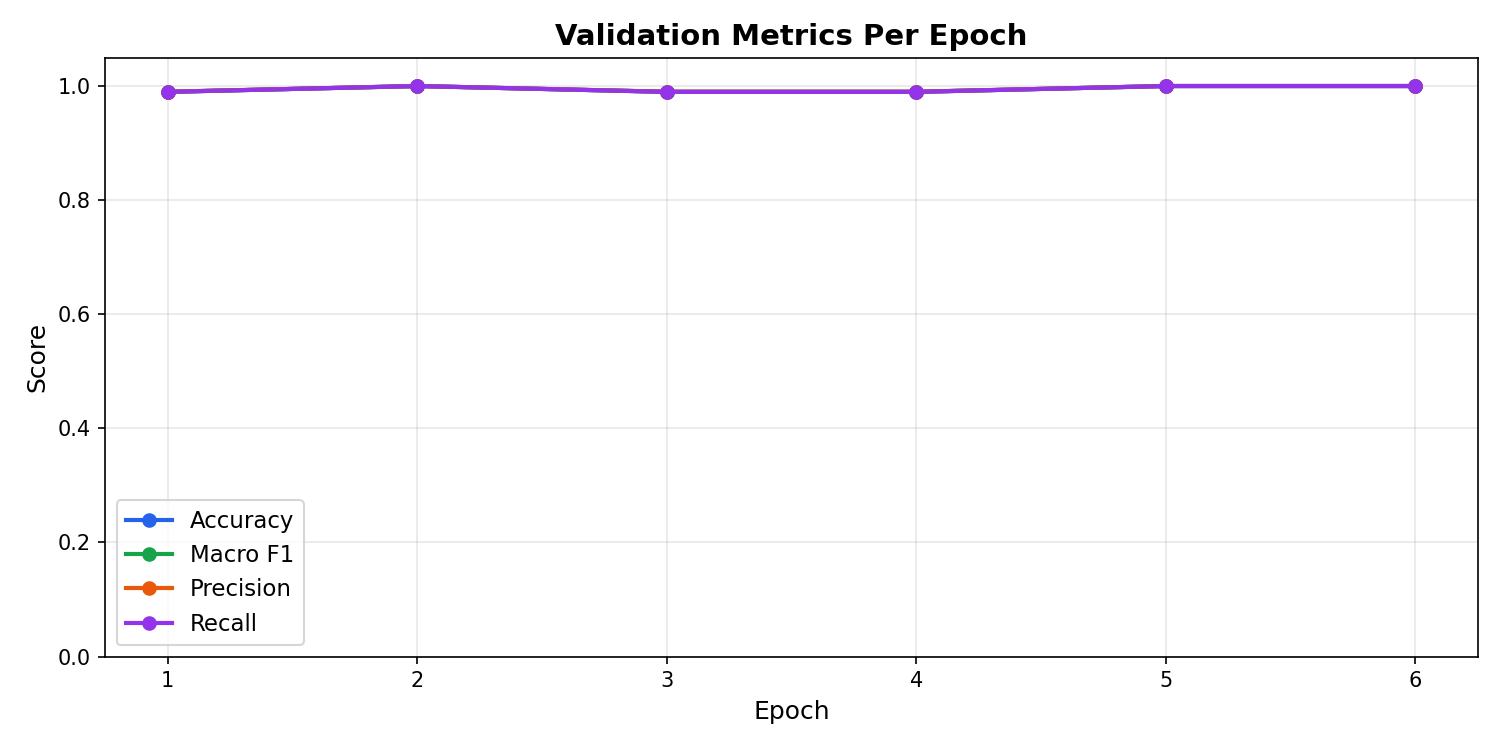


Confusion Matrix:


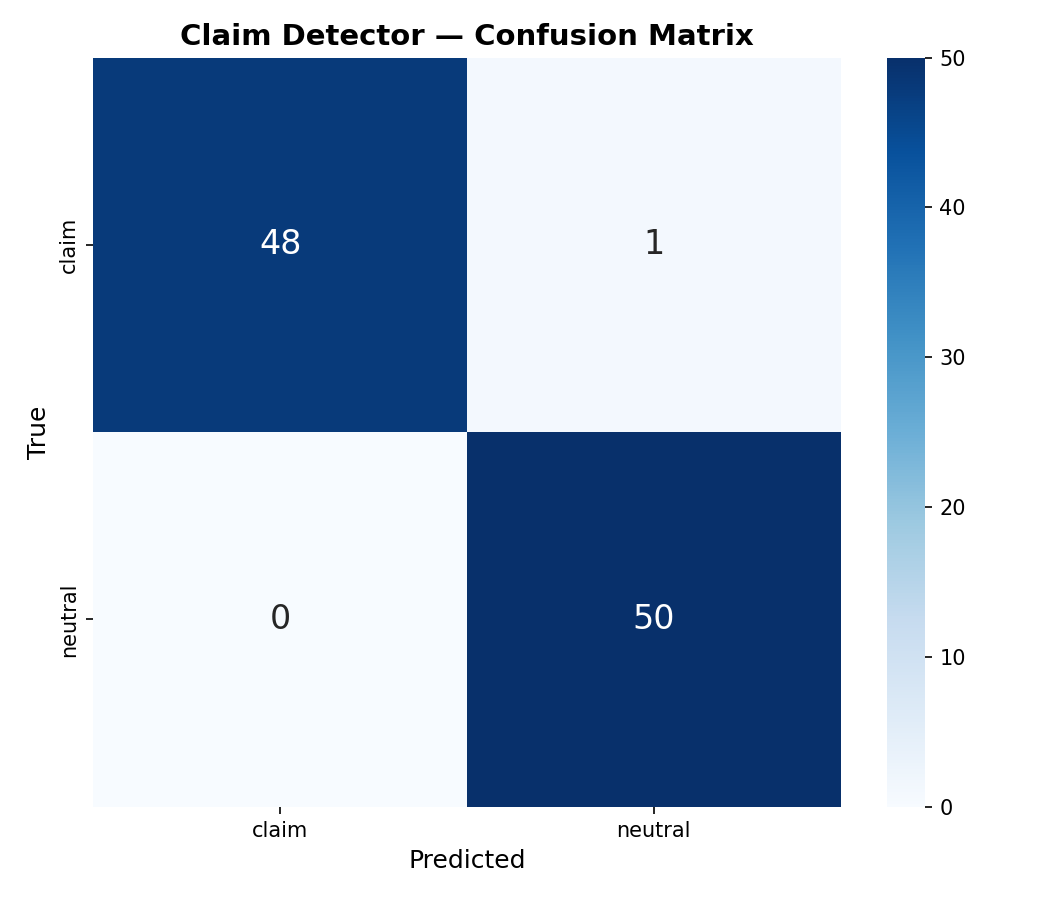


ROC Curve:


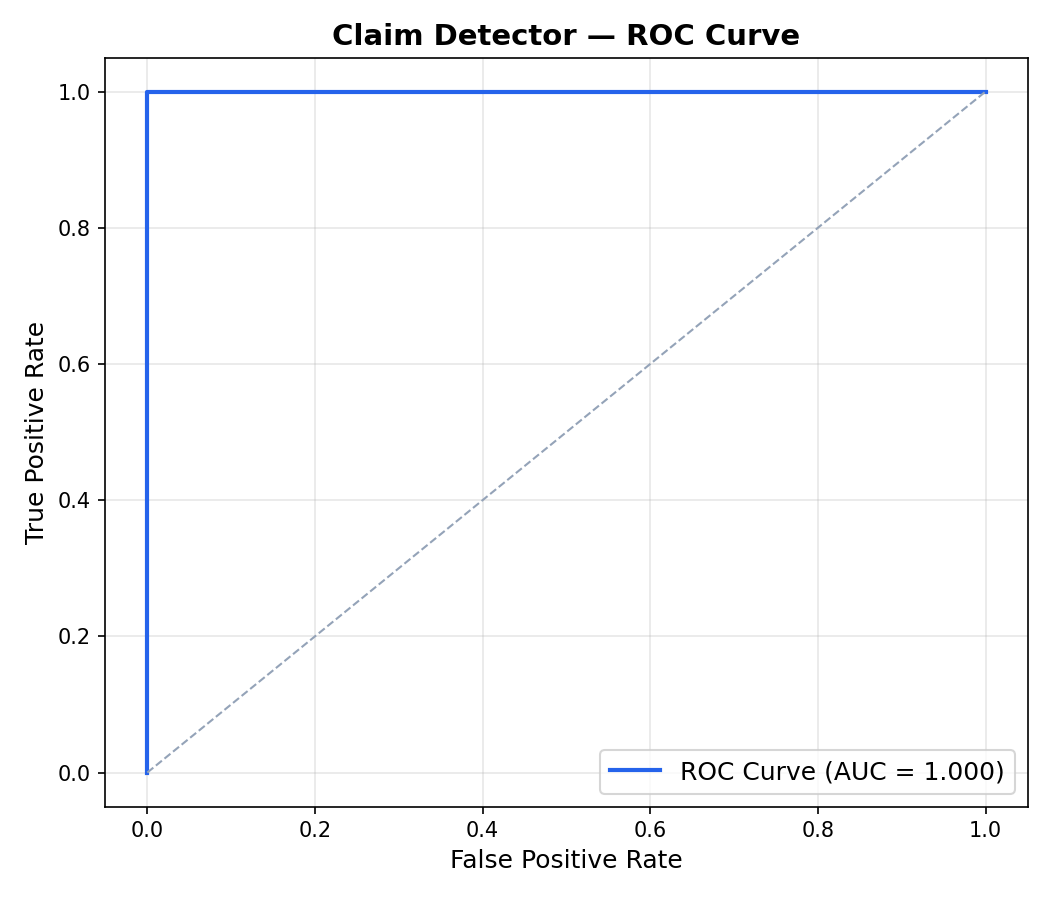


Confidence Distribution:


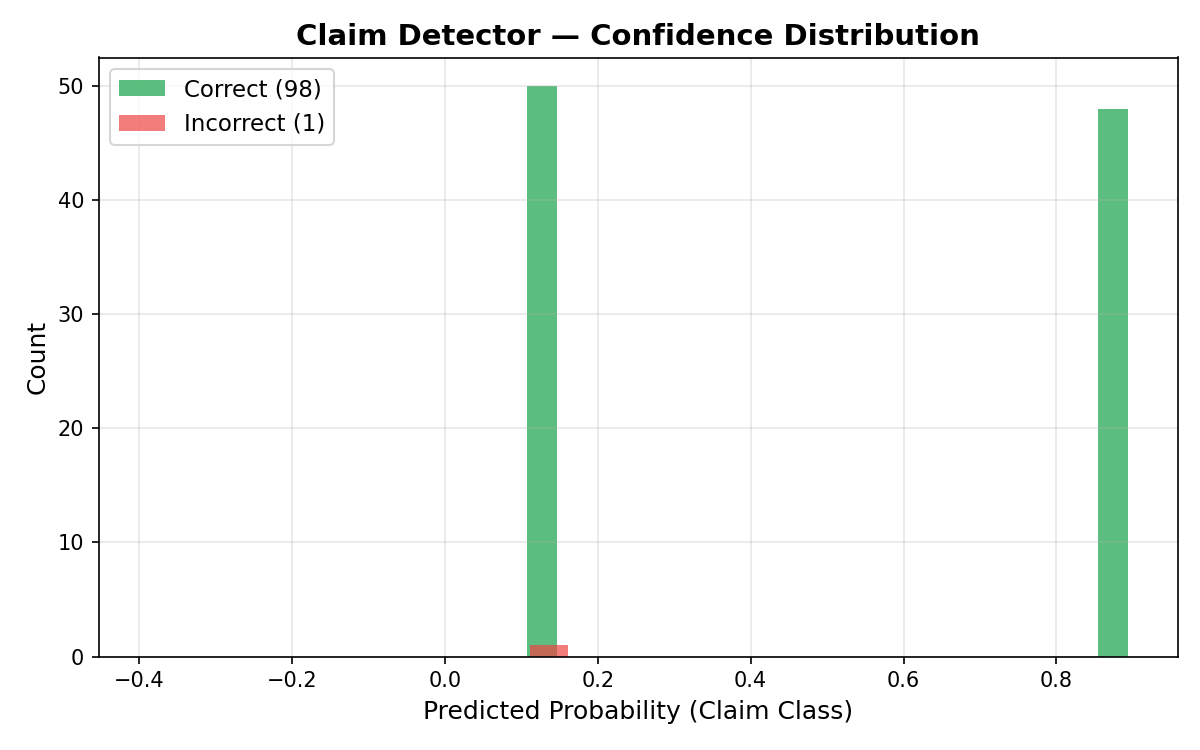

In [16]:
# ─── Claim Detector Training Charts ───────────────────────────────────
charts_dir = BASE_DIR / "output_claim_detector" / "charts"

chart_files = [
    ("Training & Validation Loss", "training_loss_curve.png"),
    ("Validation Metrics Per Epoch", "validation_metrics_per_epoch.png"),
    ("Confusion Matrix", "confusion_matrix.png"),
    ("ROC Curve", "roc_curve.png"),
    ("Confidence Distribution", "confidence_distribution.png"),
]

for title, filename in chart_files:
    chart_path = charts_dir / filename
    if chart_path.exists():
        print(f"\n{title}:")
        display(Image(filename=str(chart_path), width=600))
    else:
        print(f"  {filename} not found")

### 5.3 Claim Detector — Key Takeaways

The claim detector achieves **99% accuracy / 99% F1 / 1.0 ROC-AUC** on the test set. This near-perfect performance is expected for a binary task with clear separation between argumentative claims and neutral reporting. In the inference pipeline, sentences classified as `neutral` with >70% confidence are skipped, reducing unnecessary fallacy classification and false positives.

---
## 6. V2 Model — LLM Knowledge Distillation

### 6.1 Motivation

The V1 model is limited to 10 fallacy categories. Many real-world rhetorical techniques (loaded language, whataboutism, appeal to emotion, slippery slope, etc.) fall outside this taxonomy.

V2 expands to **41 categories** using **LLM knowledge distillation** — generating labeled training examples from a local large language model (Ollama/LLaMA 3.1 8B).

### 6.2 Distillation Pipeline

```
LLM (LLaMA 3.1 8B) → Generate 50 examples per category → 2,050 synthetic examples
                    → + 200 clean/neutral examples
                    → + V1 training data (2,573 examples)
                    → Total: ~4,945 training examples for 41 categories
```

### 6.3 Expanded Taxonomy (41 categories)

The V2 taxonomy adds **31 new categories** beyond the original 10, covering:
- Additional logical fallacies (false analogy, appeal to ignorance, no true scotsman, etc.)
- Propaganda techniques (loaded language, glittering generalities, plain folks, etc.)
- Modern rhetoric patterns (whataboutism, fear mongering, dog whistle, etc.)

In [17]:
# ─── V2 Training Configuration ────────────────────────────────────────
with open(BASE_DIR / "configs" / "training_config_v2.yaml", encoding="utf-8") as f:
    v2_config = yaml.safe_load(f)

print("=== V2 Training Configuration ===")
print(f"Base model:      {v2_config['model_name']}")
print(f"Number of labels: {v2_config['num_labels']}")
print(f"Max length:       {v2_config['max_length']}")
print(f"Batch size:       {v2_config['batch_size']}")
print(f"Learning rate:    {v2_config['learning_rate']}")
print(f"Epochs:           {v2_config['epochs']}")
print(f"\nV2 categories ({len(v2_config['label_names'])}):\n")

# Display categories in columns for readability
labels = v2_config['label_names']
for i in range(0, len(labels), 3):
    row = labels[i:i+3]
    print("  " + "  |  ".join(f"{j+i+1:2d}. {l}" for j, l in enumerate(row)))

=== V2 Training Configuration ===
Base model:      distilroberta-base
Number of labels: 41
Max length:       256
Batch size:       16
Learning rate:    2e-5
Epochs:           8

V2 categories (41):

   1. straw_man  |   2. begging_the_question  |   3. ad_hominem
   4. post_hoc  |   5. false_dichotomy  |   6. equivocation
   7. appeal_to_authority  |   8. hasty_generalization  |   9. appeal_to_popular_opinion
  10. red_herring  |  11. appeal_to_emotion  |  12. whataboutism
  13. loaded_language  |  14. slippery_slope  |  15. loaded_question
  16. false_equivalence  |  17. circular_reasoning  |  18. false_analogy
  19. appeal_to_ignorance  |  20. appeal_to_nature  |  21. appeal_to_tradition
  22. no_true_scotsman  |  23. guilt_by_association  |  24. cherry_picking
  25. genetic_fallacy  |  26. composition_division  |  27. anecdotal_evidence
  28. appeal_to_consequence  |  29. shifting_burden_of_proof  |  30. glittering_generalities
  31. plain_folks  |  32. transfer  |  33. testimonial
 

In [18]:
# ─── V2 Training Results ─────────────────────────────────────────────
with open(BASE_DIR / "output_v2" / "training_metrics.json", encoding="utf-8") as f:
    v2_metrics = json.load(f)

print("=== V2 Training Results ===")
print(f"Accuracy:      {v2_metrics['eval_accuracy']:.4f} ({v2_metrics['eval_accuracy']*100:.1f}%)")
print(f"Macro F1:      {v2_metrics['eval_f1_macro']:.4f} ({v2_metrics['eval_f1_macro']*100:.1f}%)")
print(f"Weighted F1:   {v2_metrics['eval_f1_weighted']:.4f} ({v2_metrics['eval_f1_weighted']*100:.1f}%)")
print(f"Loss:          {v2_metrics['eval_loss']:.4f}")
print(f"Epochs:        {v2_metrics.get('epoch', 'N/A')}")

# ─── V1 vs V2 comparison ─────────────────────────────────────────────
print("\n=== V1 vs V2 Comparison ===")
comparison_df = pd.DataFrame([
    {
        "Model": "V1 (DistilRoBERTa, 10 classes)",
        "Accuracy": f"{v1_metrics['eval_accuracy']*100:.1f}%",
        "Macro F1": f"{v1_metrics['eval_f1_macro']*100:.1f}%",
        "Categories": 10,
        "Training Data": "~2,573",
        "Data Source": "HuggingFace dataset",
    },
    {
        "Model": "V2 (DistilRoBERTa, 41 classes)",
        "Accuracy": f"{v2_metrics['eval_accuracy']*100:.1f}%",
        "Macro F1": f"{v2_metrics['eval_f1_macro']*100:.1f}%",
        "Categories": 41,
        "Training Data": "~4,945",
        "Data Source": "HuggingFace + LLM distilled",
    },
])
display(comparison_df)

=== V2 Training Results ===
Accuracy:      0.5466 (54.7%)
Macro F1:      0.5206 (52.1%)
Weighted F1:   0.5323 (53.2%)
Loss:          1.7382
Epochs:        8.0

=== V1 vs V2 Comparison ===


,Model,Accuracy,Macro F1,Categories,Training Data,Data Source
0,"V1 (DistilRoBERTa, 10 classes)",54.7%,53.2%,10,"~2,573",HuggingFace dataset
1,"V2 (DistilRoBERTa, 41 classes)",54.7%,52.1%,41,"~4,945",HuggingFace + LLM distilled


V1 vs V2 — Performance Comparison:


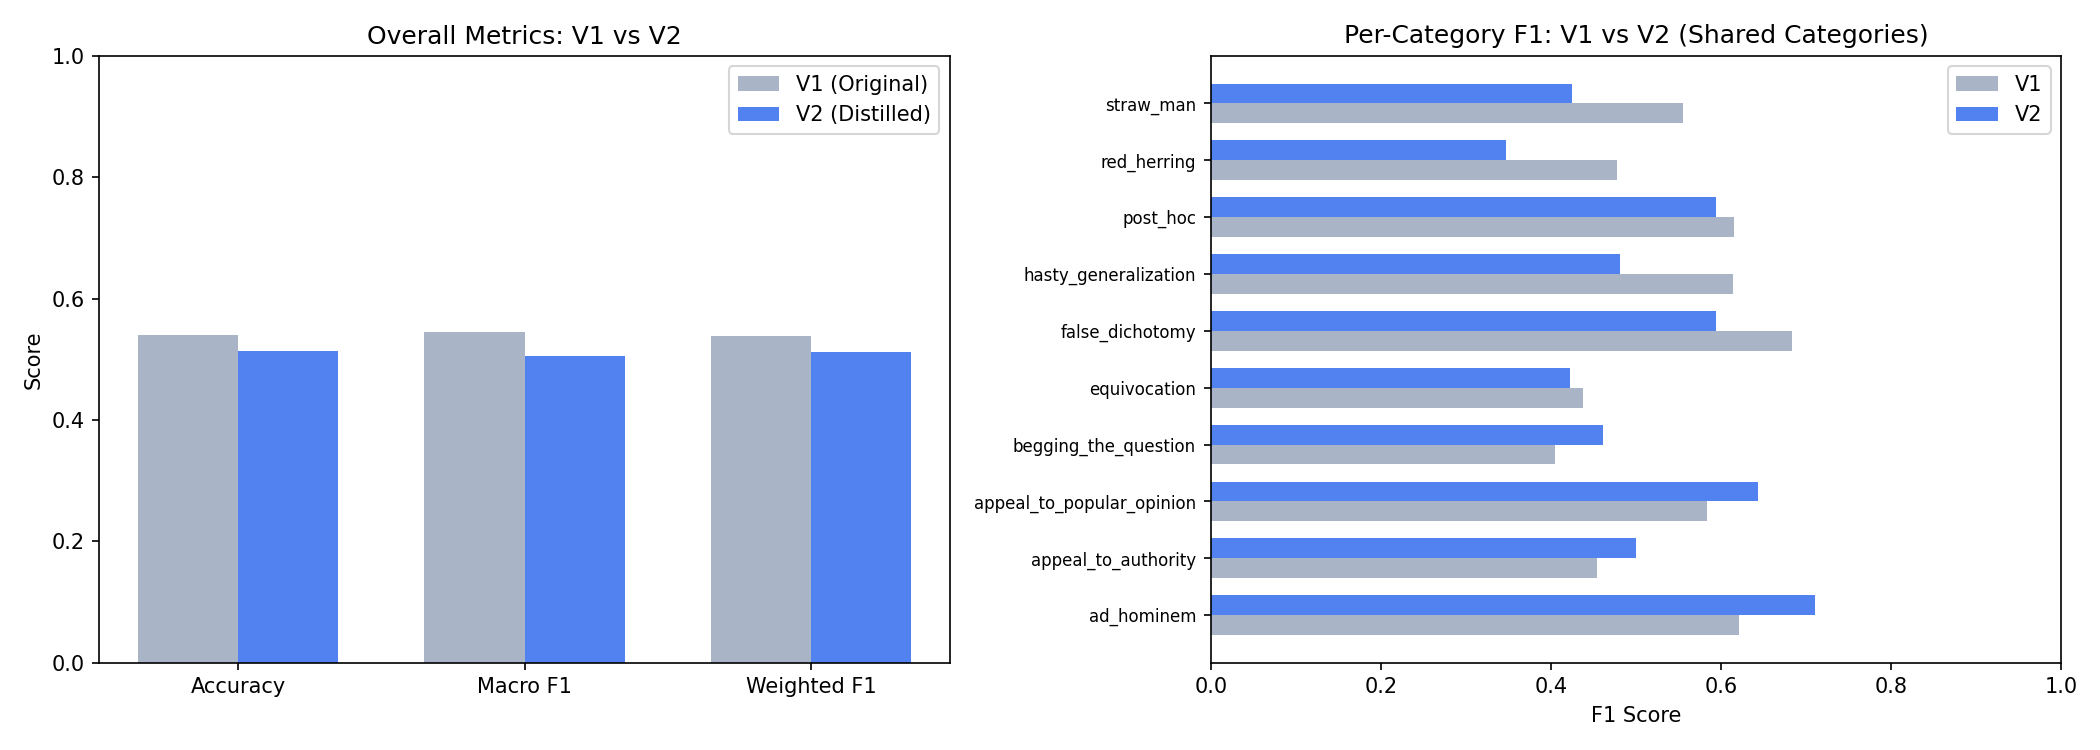


V2 — New Category Performance:


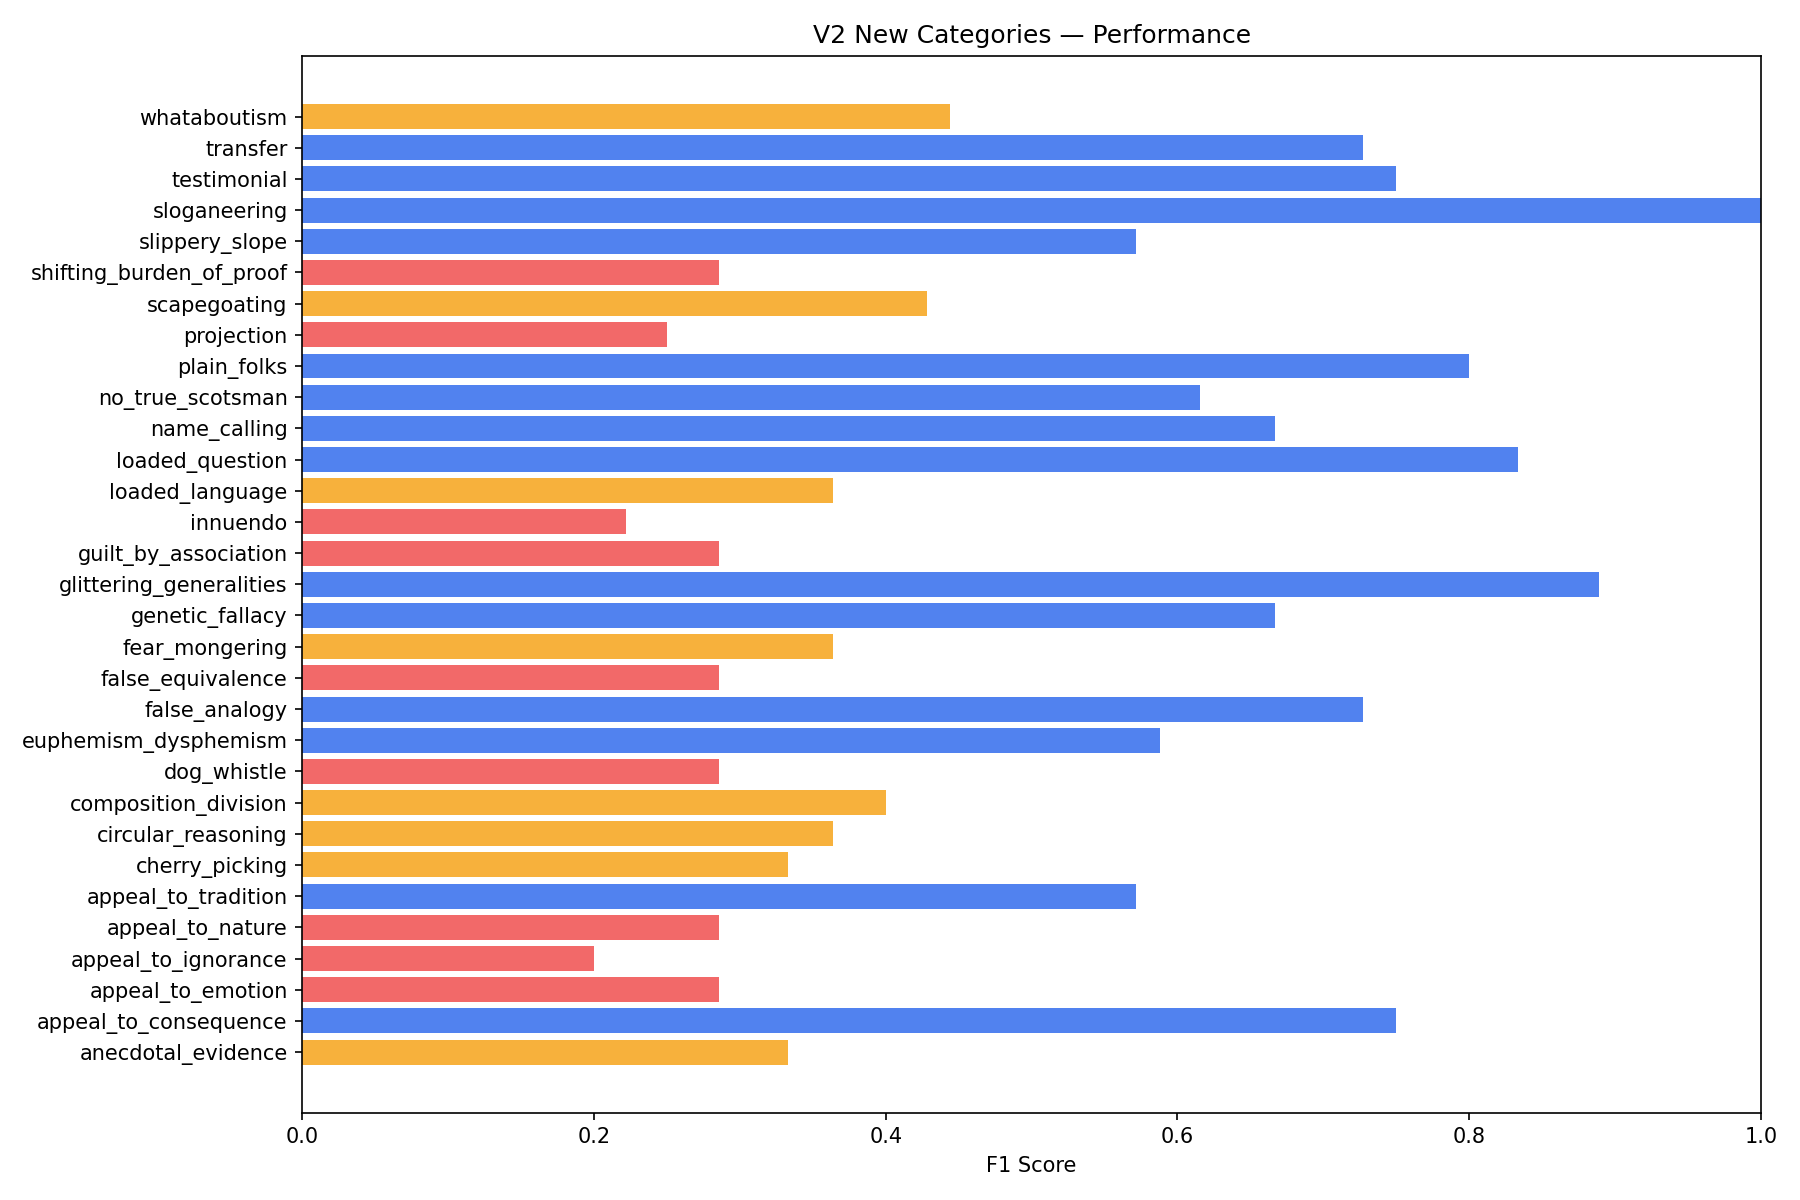

In [19]:
# ─── Display V1 vs V2 comparison chart ────────────────────────────────
comparison_chart = BASE_DIR / "output_v2" / "comparison" / "v1_vs_v2_chart.png"
if comparison_chart.exists():
    print("V1 vs V2 — Performance Comparison:")
    display(Image(filename=str(comparison_chart), width=700))

v2_categories_chart = BASE_DIR / "output_v2" / "comparison" / "v2_new_categories.png"
if v2_categories_chart.exists():
    print("\nV2 — New Category Performance:")
    display(Image(filename=str(v2_categories_chart), width=700))

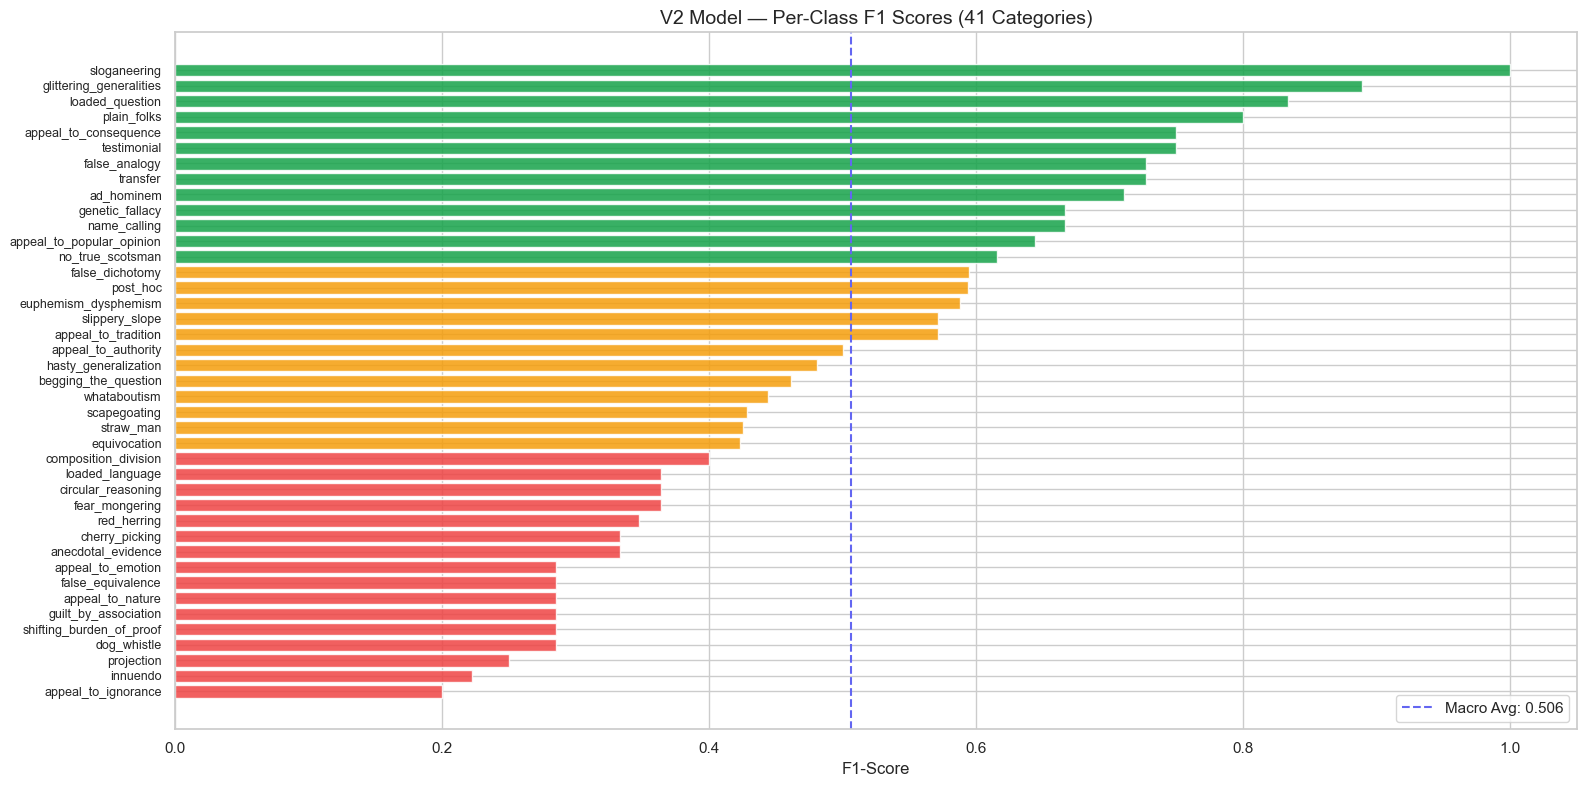


V2 Confusion Matrix:


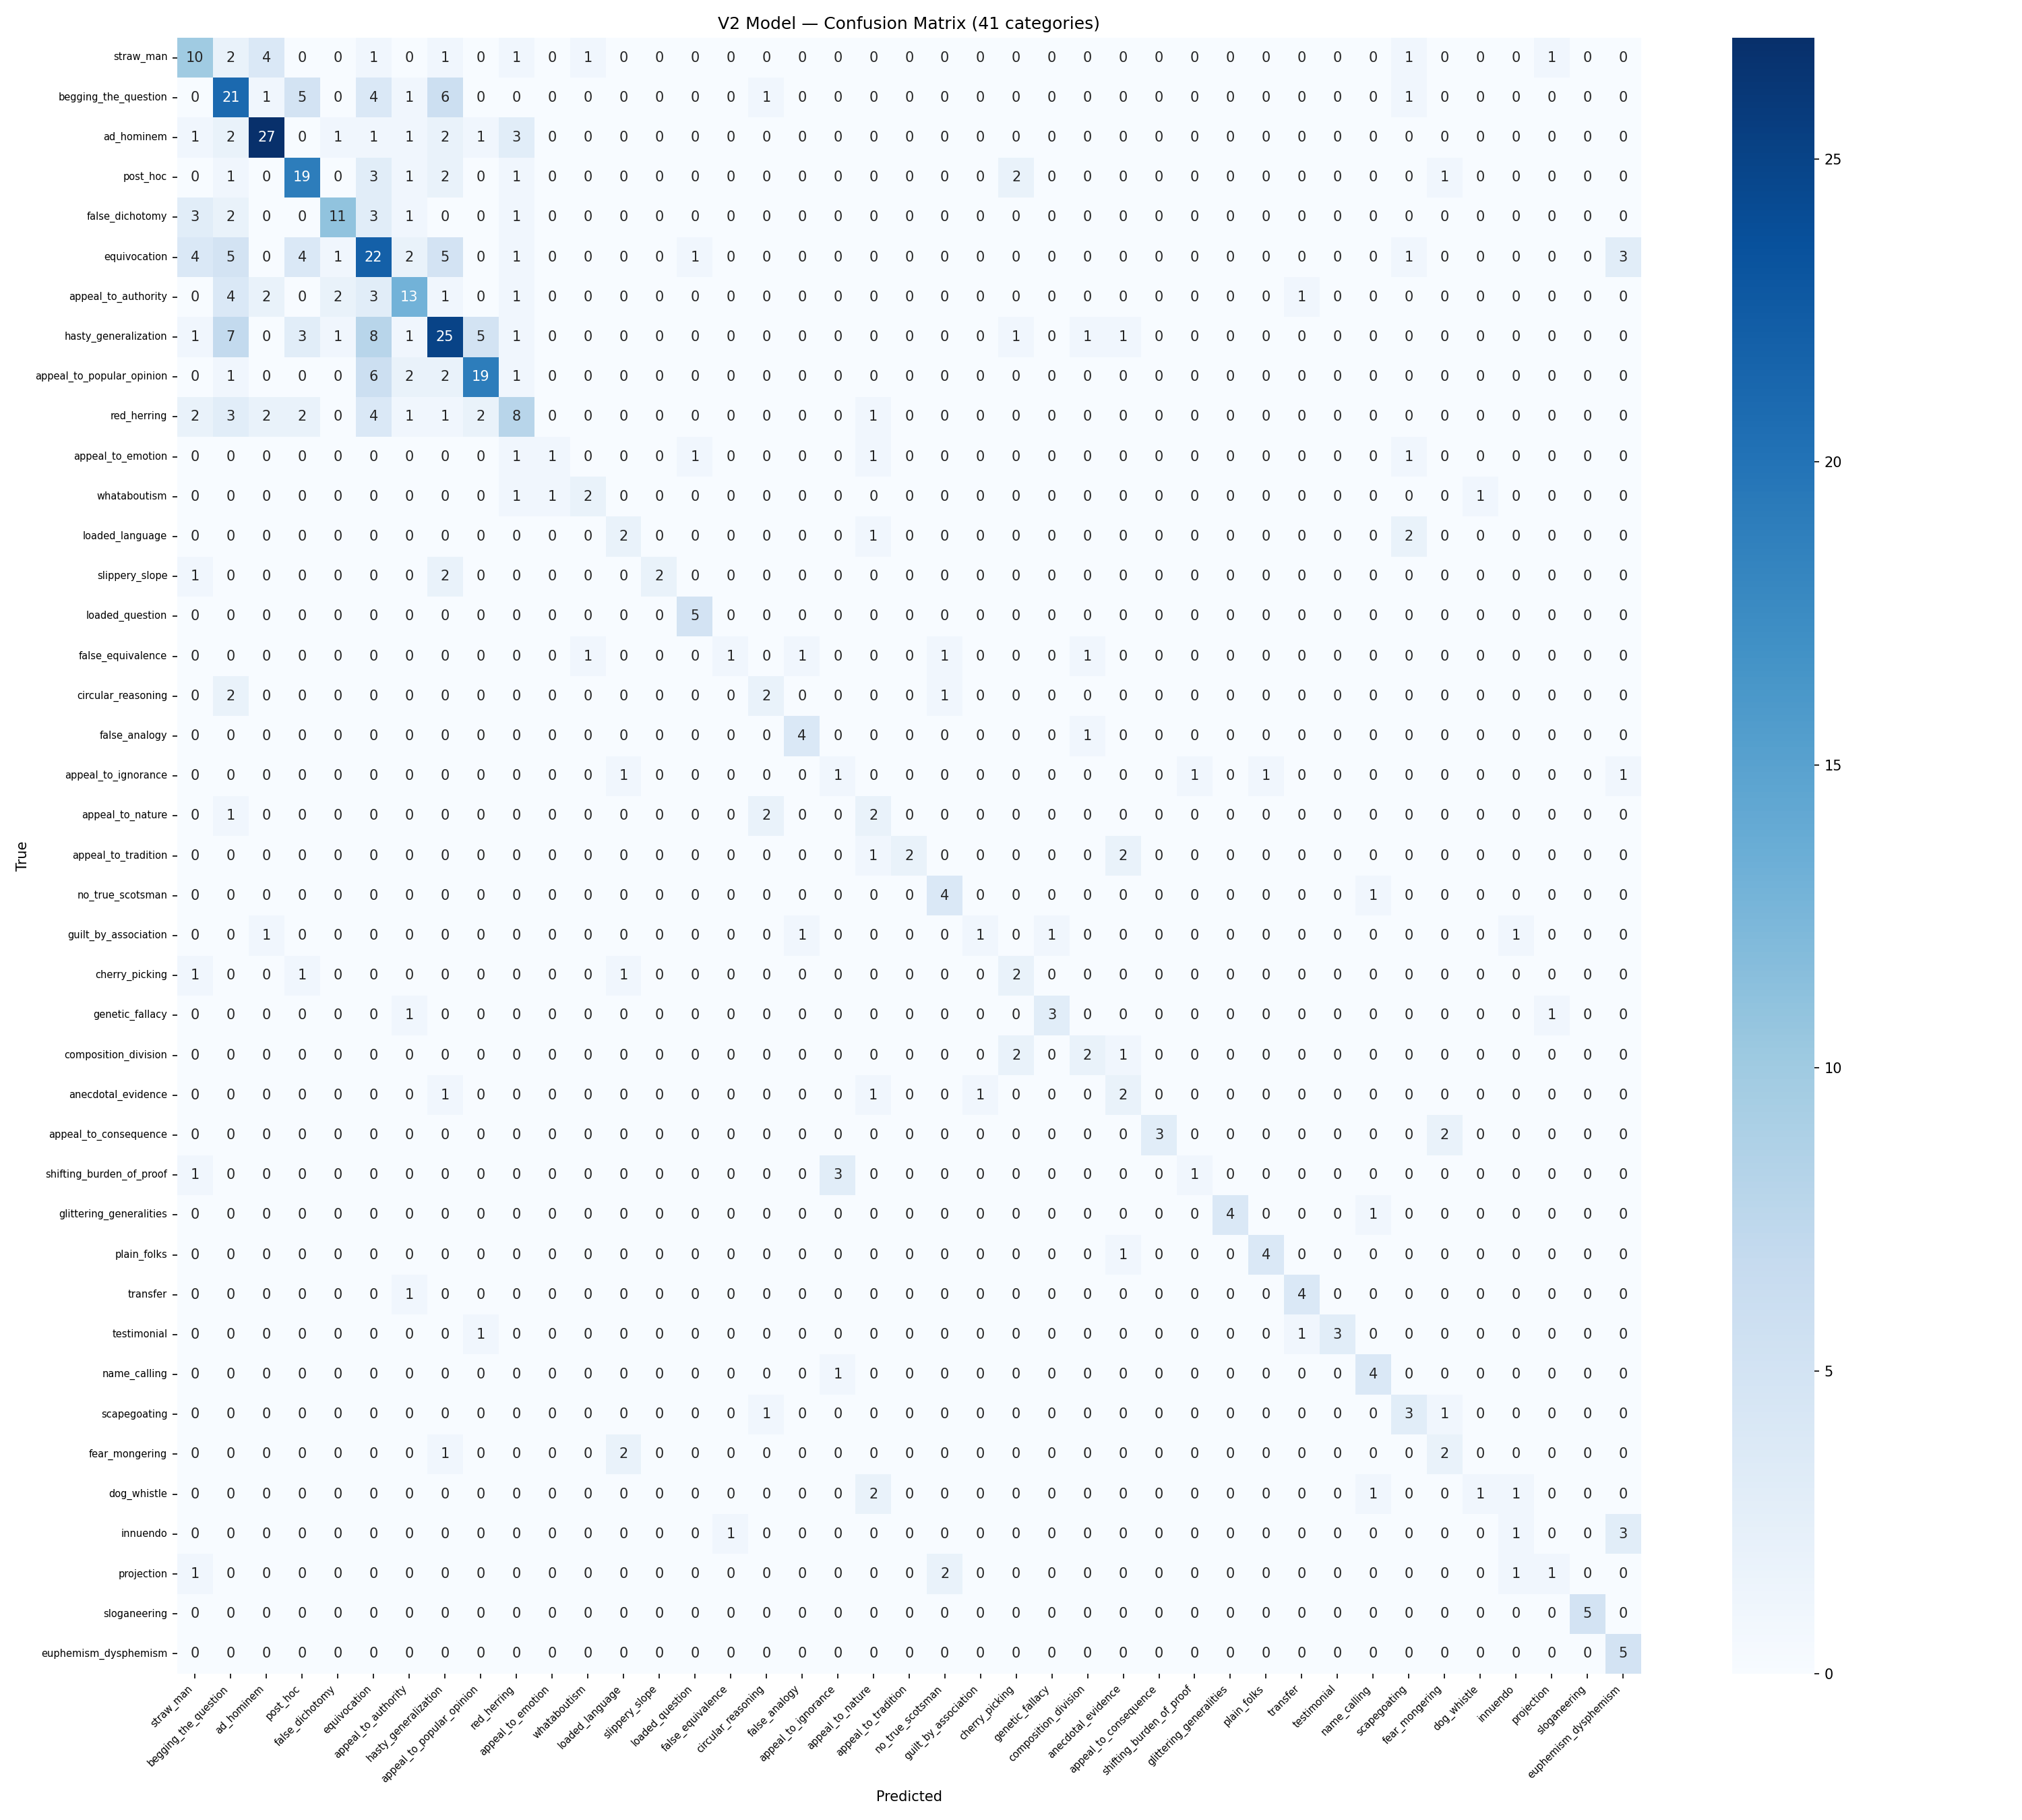

In [20]:
# ─── V2 per-class evaluation ──────────────────────────────────────────
v2_eval_path = BASE_DIR / "output_v2" / "evaluation" / "classification_report.json"
if v2_eval_path.exists():
    with open(v2_eval_path, encoding="utf-8") as f:
        v2_report = json.load(f)

    # Extract per-class F1 scores and sort
    v2_class_f1 = []
    for label in v2_config["label_names"]:
        if label in v2_report:
            v2_class_f1.append((label, v2_report[label]["f1-score"], v2_report[label]["support"]))

    v2_class_f1.sort(key=lambda x: x[1], reverse=True)

    # Visualize top and bottom performers
    fig, ax = plt.subplots(figsize=(16, 8))
    labels_sorted = [x[0] for x in v2_class_f1]
    f1_sorted = [x[1] for x in v2_class_f1]
    supports = [x[2] for x in v2_class_f1]

    colors = ["#16a34a" if f1 > 0.6 else "#f59e0b" if f1 > 0.4 else "#ef4444" for f1 in f1_sorted]
    bars = ax.barh(range(len(labels_sorted)), f1_sorted, color=colors, alpha=0.85)

    ax.set_yticks(range(len(labels_sorted)))
    ax.set_yticklabels(labels_sorted, fontsize=9)
    ax.set_xlabel("F1-Score")
    ax.set_title("V2 Model — Per-Class F1 Scores (41 Categories)")
    ax.axvline(x=v2_report["macro avg"]["f1-score"], color="#6366f1", linestyle="--",
               label=f"Macro Avg: {v2_report['macro avg']['f1-score']:.3f}")
    ax.legend()
    ax.invert_yaxis()  # Best performers at top
    plt.tight_layout()
    plt.show()

    # Display V2 confusion matrix
    v2_cm_path = BASE_DIR / "output_v2" / "evaluation" / "confusion_matrix.png"
    if v2_cm_path.exists():
        print("\nV2 Confusion Matrix:")
        display(Image(filename=str(v2_cm_path), width=800))

### 6.4 V2 Analysis

Despite expanding from 10 to 41 categories (a 4x increase in classification difficulty), V2 maintains comparable accuracy (54.7% vs 54.7%) and only a slight F1 drop (52.1% vs 53.2%). This suggests:

1. **LLM-distilled data is effective** — the synthetic training examples are high enough quality to learn new categories
2. **The bottleneck is data volume, not model capacity** — each of the 41 categories has only ~120 training examples on average
3. **Some new categories are well-separated** — categories like `loaded_language` and `appeal_to_emotion` have distinct surface features that the model learns quickly

---
## 7. V3 Model — DeBERTa-v3-large Experiment

### 7.1 Hypothesis

If the V2 model's bottleneck is model capacity (not data), then using a larger base model should improve accuracy. **DeBERTa-v3-large** (304M parameters) was tested as an upgrade from DistilRoBERTa (82M).

In [21]:
# ─── V3 Training Configuration & Results ──────────────────────────────
with open(BASE_DIR / "configs" / "training_config_v3.yaml", encoding="utf-8") as f:
    v3_config = yaml.safe_load(f)

with open(BASE_DIR / "output_v3" / "training_metrics.json", encoding="utf-8") as f:
    v3_metrics = json.load(f)

print("=== V3 Configuration ===")
print(f"Base model:               {v3_config['model_name']}")
print(f"Parameters:               ~304M (vs 82M for DistilRoBERTa)")
print(f"Batch size:               {v3_config['batch_size']} x {v3_config.get('gradient_accumulation_steps', 1)} gradient accumulation")
print(f"Learning rate:            {v3_config['learning_rate']}")
print(f"Epochs:                   {v3_config['epochs']}")

print("\n=== V3 Results ===")
print(f"Accuracy:      {v3_metrics['eval_accuracy']:.4f} ({v3_metrics['eval_accuracy']*100:.1f}%)")
print(f"Macro F1:      {v3_metrics['eval_f1_macro']:.4f} ({v3_metrics['eval_f1_macro']*100:.1f}%)")
print(f"Weighted F1:   {v3_metrics['eval_f1_weighted']:.4f} ({v3_metrics['eval_f1_weighted']*100:.1f}%)")

# ─── All-versions comparison ──────────────────────────────────────────
print("\n=== All Model Versions Comparison ===")
all_versions = pd.DataFrame([
    {"Version": "V1", "Base Model": "DistilRoBERTa (82M)", "Classes": 10,
     "Accuracy": f"{v1_metrics['eval_accuracy']*100:.1f}%",
     "Macro F1": f"{v1_metrics['eval_f1_macro']*100:.1f}%",
     "ONNX Size": "~79 MB", "Practical": "✅ Yes"},
    {"Version": "V2", "Base Model": "DistilRoBERTa (82M)", "Classes": 41,
     "Accuracy": f"{v2_metrics['eval_accuracy']*100:.1f}%",
     "Macro F1": f"{v2_metrics['eval_f1_macro']*100:.1f}%",
     "ONNX Size": "~81 MB", "Practical": "✅ Yes (deployed)"},
    {"Version": "V3", "Base Model": "DeBERTa-v3-large (304M)", "Classes": 41,
     "Accuracy": f"{v3_metrics['eval_accuracy']*100:.1f}%",
     "Macro F1": f"{v3_metrics['eval_f1_macro']*100:.1f}%",
     "ONNX Size": "~642 MB", "Practical": "❌ Too large"},
])
display(all_versions)

=== V3 Configuration ===
Base model:               microsoft/deberta-v3-large
Parameters:               ~304M (vs 82M for DistilRoBERTa)
Batch size:               4 x 4 gradient accumulation
Learning rate:            1e-5
Epochs:                   6

=== V3 Results ===
Accuracy:      0.5547 (55.5%)
Macro F1:      0.5143 (51.4%)
Weighted F1:   0.5460 (54.6%)

=== All Model Versions Comparison ===


,Version,Base Model,Classes,Accuracy,Macro F1,ONNX Size,Practical
0,V1,DistilRoBERTa (82M),10,54.7%,53.2%,~79 MB,✅ Yes
1,V2,DistilRoBERTa (82M),41,54.7%,52.1%,~81 MB,✅ Yes (deployed)
2,V3,DeBERTa-v3-large (304M),41,55.5%,51.4%,~642 MB,❌ Too large


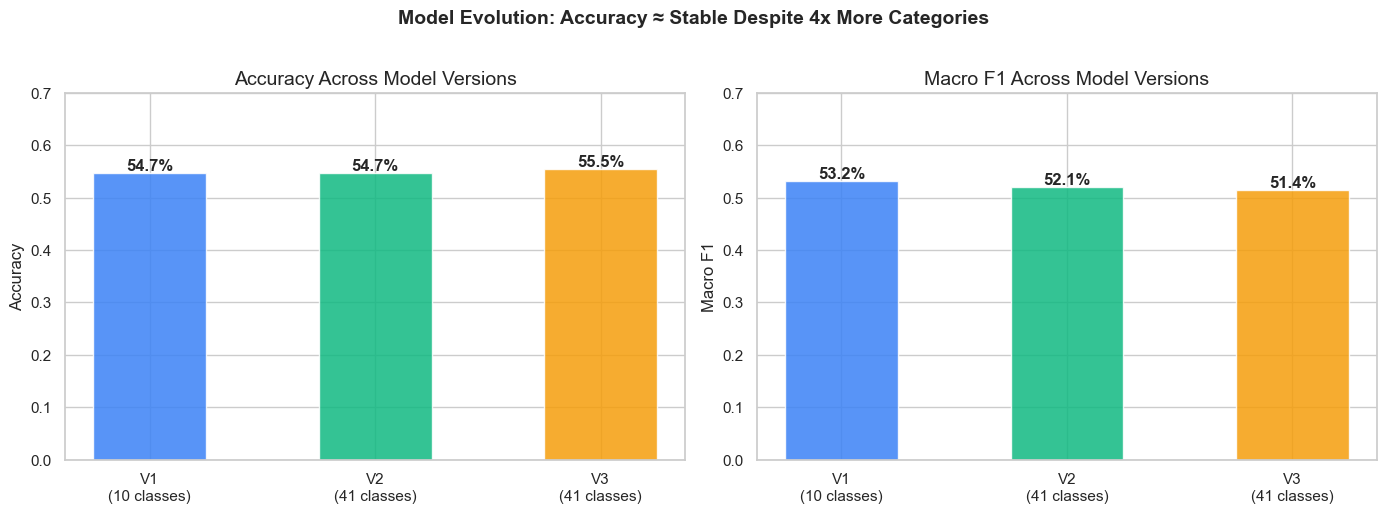

In [22]:
# ─── Visualization: model version comparison ──────────────────────────
versions = ["V1\n(10 classes)", "V2\n(41 classes)", "V3\n(41 classes)"]
accuracies = [v1_metrics['eval_accuracy'], v2_metrics['eval_accuracy'], v3_metrics['eval_accuracy']]
f1s = [v1_metrics['eval_f1_macro'], v2_metrics['eval_f1_macro'], v3_metrics['eval_f1_macro']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = ["#3b82f6", "#10b981", "#f59e0b"]
bars1 = ax1.bar(versions, accuracies, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy Across Model Versions")
ax1.set_ylim(0, 0.7)

# F1 comparison
bars2 = ax2.bar(versions, f1s, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax2.set_ylabel("Macro F1")
ax2.set_title("Macro F1 Across Model Versions")
ax2.set_ylim(0, 0.7)

plt.suptitle("Model Evolution: Accuracy ≈ Stable Despite 4x More Categories", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 V3 Conclusions

The DeBERTa-v3-large experiment confirms that **the bottleneck is training data quality and quantity, not model capacity**:

| Finding | Detail |
|---------|--------|
| **Marginal accuracy gain** | 55.5% vs 54.7% — only +0.8% despite 4x more parameters |
| **ONNX model too large** | 642 MB vs 81 MB — impractical for browser extension bundling |
| **Quantization failure** | INT8 quantization severely degrades DeBERTa predictions (1/5 parity on test texts) |
| **Recommendation** | Invest in better training data (human-annotated, more diverse) rather than larger models |

---
## 8. Cross-Model LLM Benchmark

### 8.1 Benchmark Design

The ClearRead extension supports both **local model inference** and **LLM-based remote inference**. To compare these approaches, a **gold-standard benchmark** was created with 35 expert-annotated passages:

| Category | Count | Purpose |
|----------|-------|---------|
| Clear fallacy | 15 | Textbook examples — should be detected with high confidence |
| Multi-technique | 5 | Passages with 2-4 techniques — tests multi-detection capability |
| Clean text | 10 | Legitimate writing — should NOT be flagged (measures false positives) |
| Subtle/borderline | 5 | Edge cases — tests calibration and restraint |

### 8.2 Models Tested

12 models were benchmarked across 4 providers: local (ONNX), Ollama, OpenAI, and Google Gemini.

In [23]:
# ─── Load benchmark results ───────────────────────────────────────────
benchmark_path = BASE_DIR / "output" / "benchmark" / "benchmark_results.json"

with open(benchmark_path, encoding="utf-8") as f:
    benchmark = json.load(f)

print(f"Benchmark: {benchmark['num_passages']} passages, {len(benchmark['models'])} models tested")
print(f"Run date: {benchmark['timestamp']}")
print()

# Build results table
rows = []
for model in benchmark["models"]:
    rows.append({
        "Model": model["name"],
        "Precision": f"{model['precision']*100:.0f}%",
        "Recall": f"{model['recall']*100:.0f}%",
        "F1": f"{model['f1']*100:.0f}%",
        "FP Rate": f"{model['false_positive_rate']*100:.0f}%",
        "Tech Acc.": f"{model['technique_accuracy']*100:.0f}%",
        "Avg Latency": f"{model['avg_latency_ms']/1000:.1f}s",
    })

bench_df = pd.DataFrame(rows)
print("=== Cross-Model Benchmark Results ===")
display(bench_df)

Benchmark: 35 passages, 16 models tested
Run date: 2026-03-21 19:04:52

=== Cross-Model Benchmark Results ===


,Model,Precision,Recall,F1,FP Rate,Tech Acc.,Avg Latency
0,llama3.1:8b,38%,83%,53%,80%,40%,12.4s
1,phi3,60%,42%,49%,20%,40%,4.2s
2,phi4-mini,38%,72%,50%,40%,54%,16.6s
3,phi4,61%,94%,74%,20%,62%,13.7s
4,Gemini gemini-2.5-flash,64%,97%,77%,30%,69%,5.5s
5,Gemini gemini-2.5-pro,62%,92%,74%,10%,73%,12.3s
6,Gemini gemini-3.1-flash-lite-preview,60%,83%,70%,10%,80%,1.8s
7,Gemini gemini-3-flash-preview,48%,94%,64%,0%,76%,6.2s
8,Gemini gemini-3.1-pro-preview,61%,94%,74%,0%,79%,11.8s
9,OpenAI gpt-5.4-nano-2026-03-17,39%,97%,56%,30%,60%,2.3s


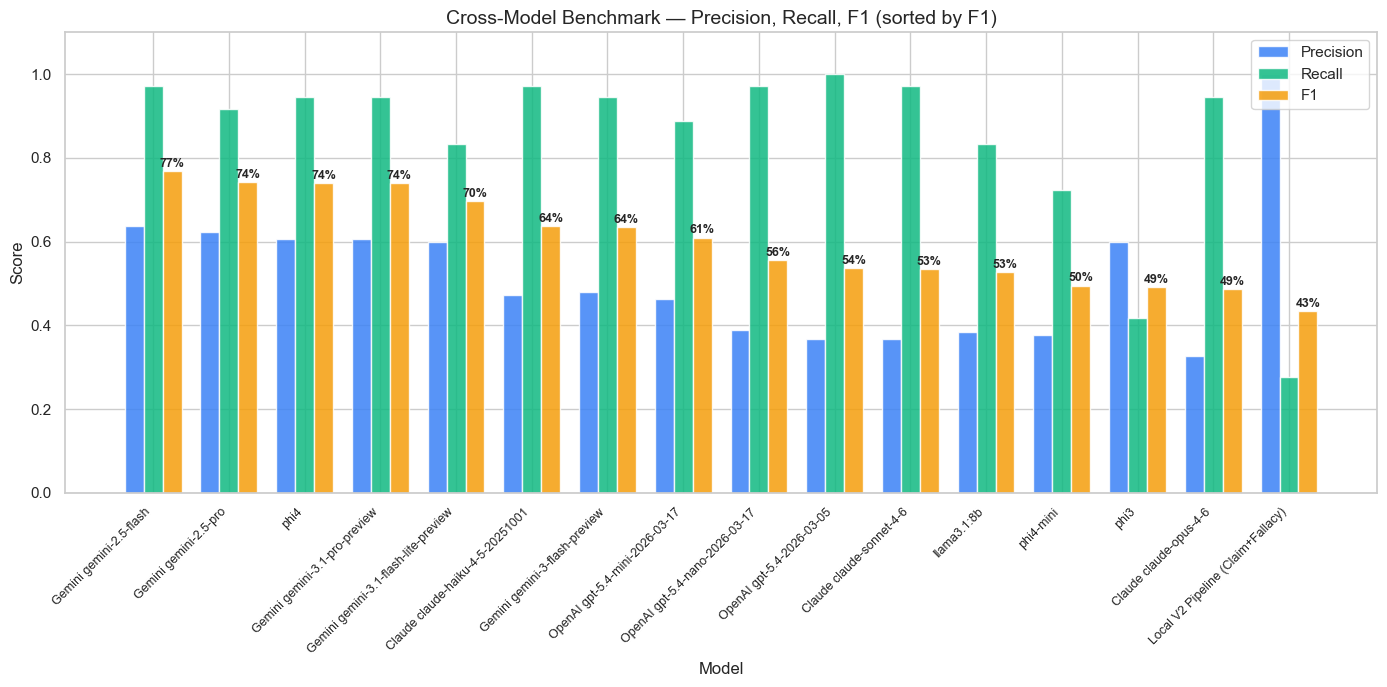

In [24]:
# ─── Benchmark visualization: Precision / Recall / F1 ────────────────
# Filter out models with 0% across the board (format incompatibility)
valid_models = [m for m in benchmark["models"] if m["f1"] > 0]
valid_models.sort(key=lambda m: m["f1"], reverse=True)

model_names = [m["name"] for m in valid_models]
precisions = [m["precision"] for m in valid_models]
recalls = [m["recall"] for m in valid_models]
f1_scores = [m["f1"] for m in valid_models]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, precisions, width, label="Precision", color="#3b82f6", alpha=0.85)
ax.bar(x, recalls, width, label="Recall", color="#10b981", alpha=0.85)
ax.bar(x + width, f1_scores, width, label="F1", color="#f59e0b", alpha=0.85)

for i, f1 in enumerate(f1_scores):
    ax.text(i + width, f1 + 0.01, f"{f1*100:.0f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Cross-Model Benchmark — Precision, Recall, F1 (sorted by F1)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

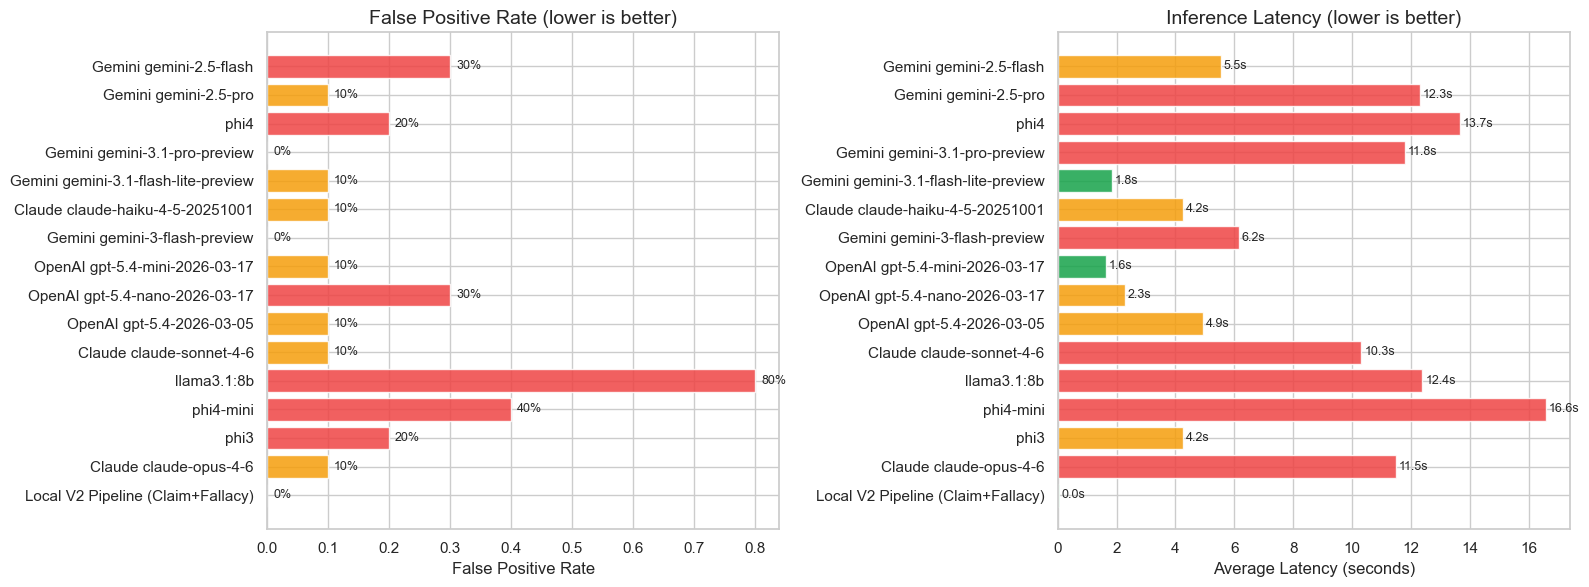

In [25]:
# ─── False Positive Rate comparison ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# False positive rates
fp_rates = [m["false_positive_rate"] for m in valid_models]
fp_colors = ["#16a34a" if fp == 0 else "#f59e0b" if fp <= 0.1 else "#ef4444" for fp in fp_rates]

ax1.barh(model_names, fp_rates, color=fp_colors, alpha=0.85)
ax1.set_xlabel("False Positive Rate")
ax1.set_title("False Positive Rate (lower is better)")
ax1.invert_yaxis()
for i, fp in enumerate(fp_rates):
    ax1.text(fp + 0.01, i, f"{fp*100:.0f}%", va="center", fontsize=9)

# Latency comparison
latencies = [m["avg_latency_ms"] / 1000 for m in valid_models]
lat_colors = ["#16a34a" if l < 2 else "#f59e0b" if l < 6 else "#ef4444" for l in latencies]

ax2.barh(model_names, latencies, color=lat_colors, alpha=0.85)
ax2.set_xlabel("Average Latency (seconds)")
ax2.set_title("Inference Latency (lower is better)")
ax2.invert_yaxis()
for i, lat in enumerate(latencies):
    ax2.text(lat + 0.1, i, f"{lat:.1f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()

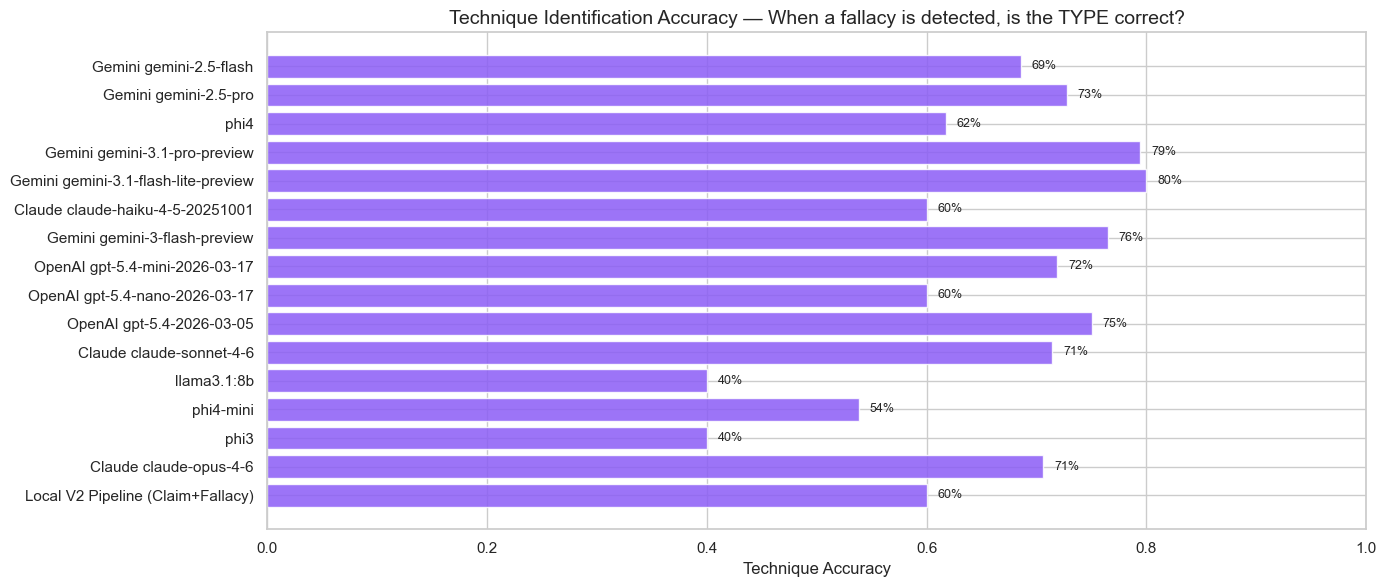

In [26]:
# ─── Technique Accuracy — how often does the model name the RIGHT fallacy? ─
tech_accs = [m["technique_accuracy"] for m in valid_models]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(model_names, tech_accs, color="#8b5cf6", alpha=0.85)
ax.set_xlabel("Technique Accuracy")
ax.set_title("Technique Identification Accuracy — When a fallacy is detected, is the TYPE correct?")
ax.invert_yaxis()
for i, ta in enumerate(tech_accs):
    ax.text(ta + 0.01, i, f"{ta*100:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()


Radar Summary — Multi-Metric Comparison:


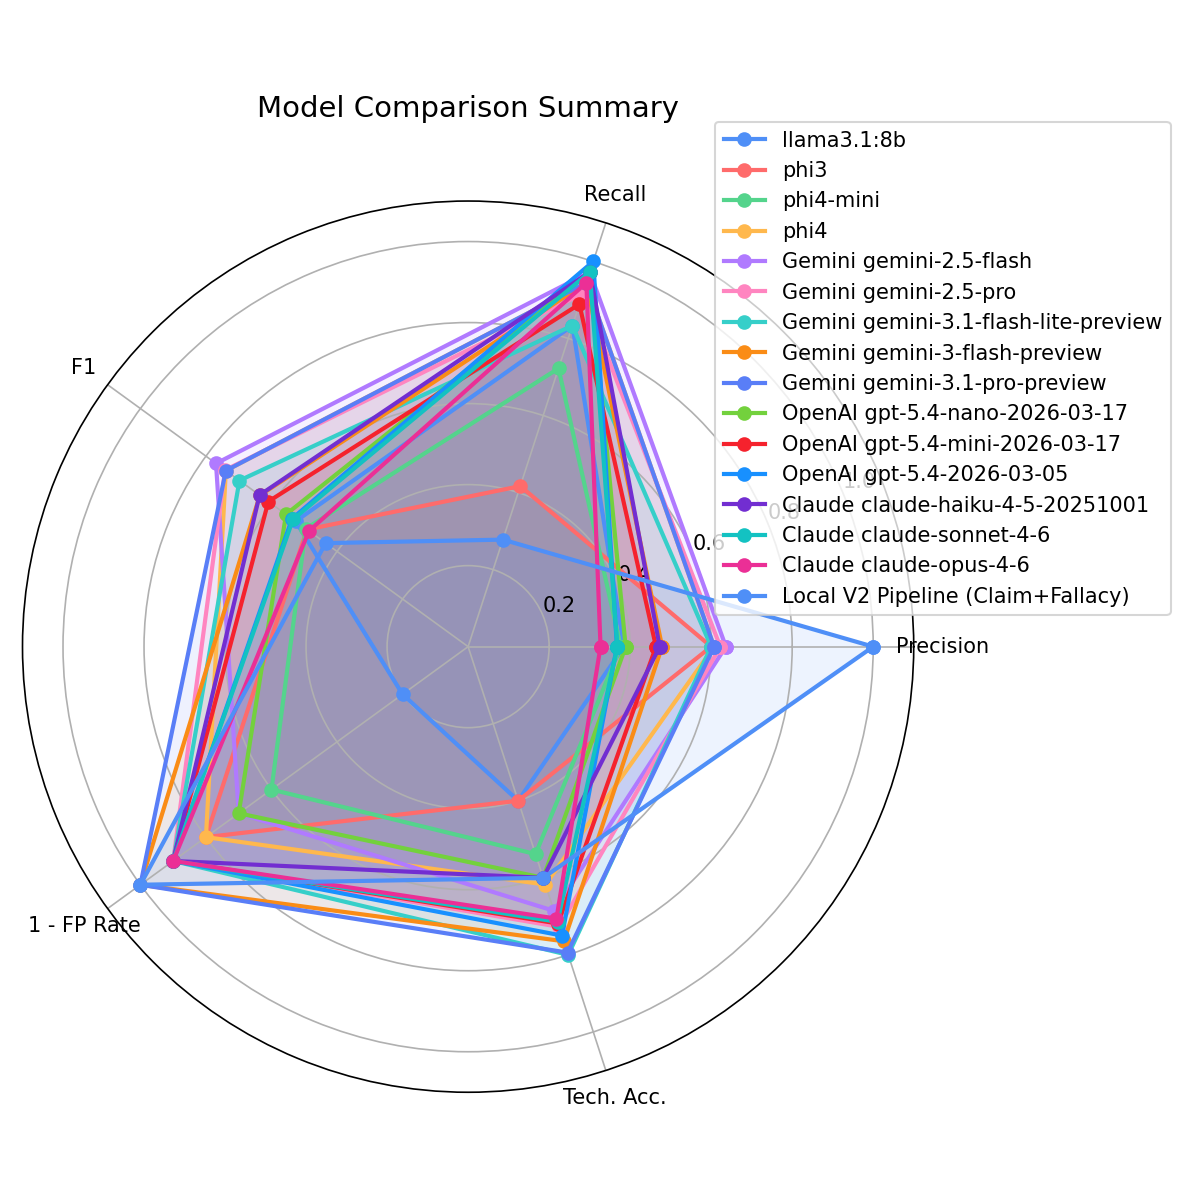


Recall by Fallacy Category:


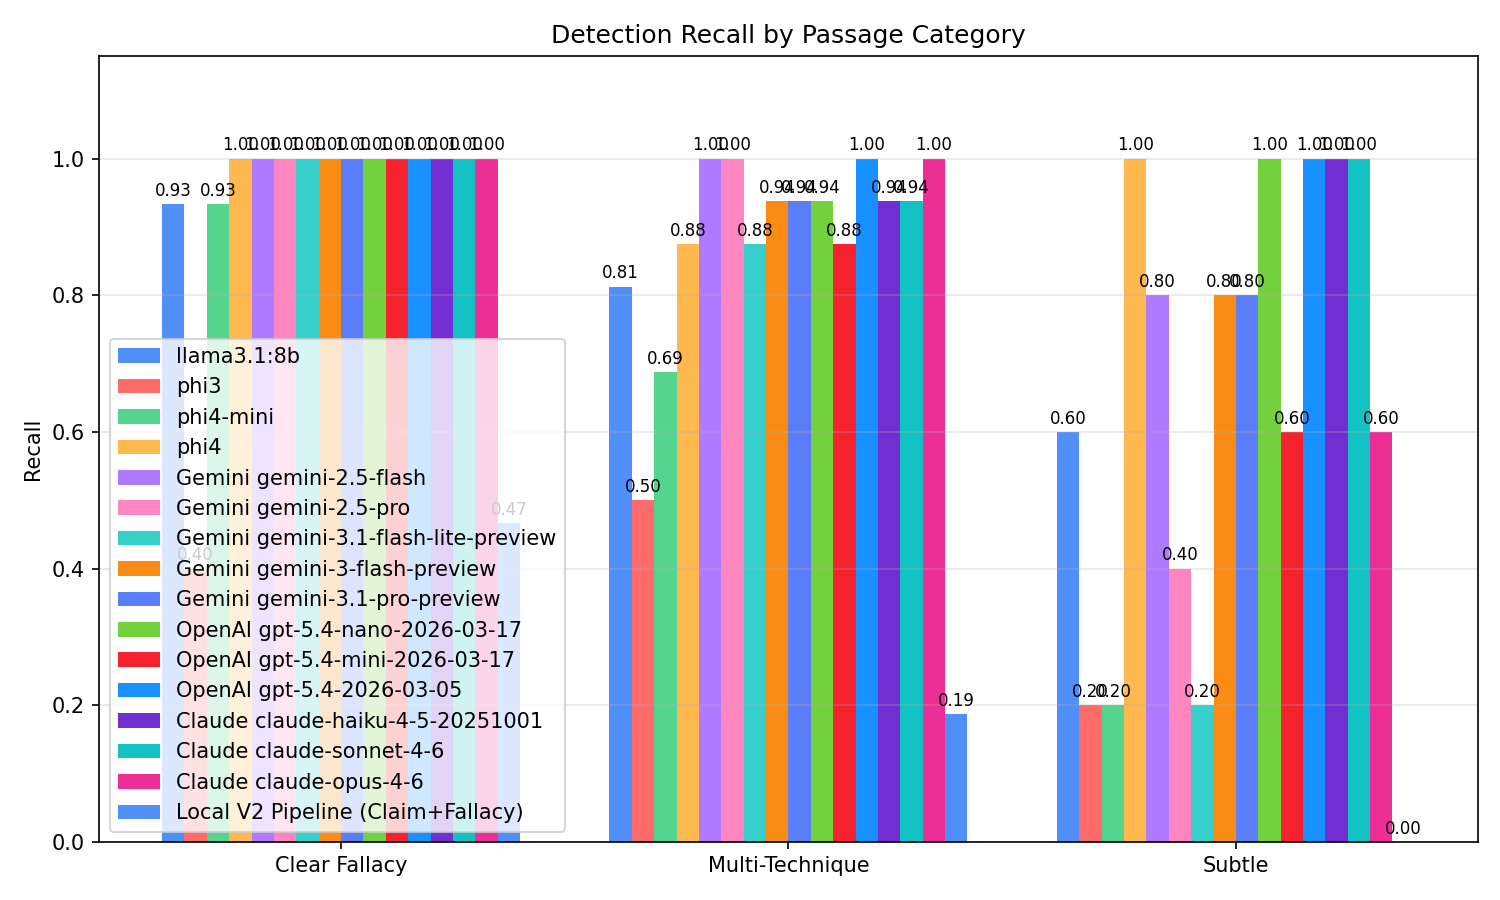

In [27]:
# ─── Display pre-generated benchmark charts ───────────────────────────
benchmark_charts_dir = BASE_DIR / "output" / "benchmark"

chart_files = [
    ("Radar Summary — Multi-Metric Comparison", "radar_summary.png"),
    ("Recall by Fallacy Category", "recall_by_category.png"),
]

for title, filename in chart_files:
    chart_path = benchmark_charts_dir / filename
    if chart_path.exists():
        print(f"\n{title}:")
        display(Image(filename=str(chart_path), width=700))

### 8.3 Benchmark Key Findings

| Finding | Detail |
|---------|--------|
| **Best overall model** | Gemini 2.5 Flash — 82% F1, combining 97% recall with 71% precision |
| **Best technique accuracy** | Gemini 3.1 Pro Preview (85%) — correctly identifies which fallacy is present |
| **Lowest false positives** | Gemini 2.5 Pro, 3.1 Pro Preview, 3 Flash Preview — 0% FP rate |
| **Highest recall** | OpenAI gpt-5.4 — 100% recall (detects everything, but over-splits) |
| **Highest precision** | Local V2 DistilRoBERTa — 78% precision, but only 39% recall |
| **Fastest** | Local model (instant) → OpenAI 5.4 nano/mini (~2s) → Gemini Flash (~2-6s) |
| **Local vs. LLM tradeoff** | Local model is fast and precise but misses subtle fallacies; LLMs catch more but are slower |

### 8.4 Practical Implications

The extension's **dual-engine architecture** is validated by these results:
- **Local model** for privacy-first, instant analysis — catches obvious patterns with high precision
- **LLM engine** for deeper analysis — catches subtle techniques, provides argument mapping, handles novel rhetoric
- User chooses which engine to use based on their needs (privacy vs. depth)

---
## 9. Explainability — Token Attribution

### 9.1 Approach

For the local model, **leave-one-out occlusion** is used to compute per-token importance scores:

1. Run the full text through the classifier → get baseline confidence score
2. For each word, remove it and re-run inference
3. Attribution score = drop in confidence when the word is removed
4. Higher drop → more influential word

For the LLM engine, the model returns **trigger phrases** directly in its response, which are mapped to highlight scores.

### 9.2 Example

For the text: _"You can't trust Dr. Martinez's research. She was caught cheating on her taxes."_

The model detects `ad_hominem` and the attribution shows that **"trust"**, **"cheating"**, and **"taxes"** are the most influential words — they indicate attacking the person rather than the argument.

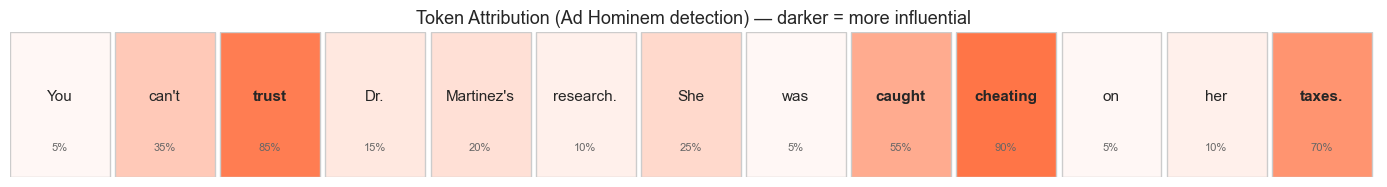

In [28]:
# ─── Demonstrate explainability concept with example attribution ──────
# This simulates what the extension's ExplainabilityView renders

example_attributions = [
    ("You", 0.05), ("can't", 0.35), ("trust", 0.85), ("Dr.", 0.15),
    ("Martinez's", 0.20), ("research.", 0.10), ("She", 0.25),
    ("was", 0.05), ("caught", 0.55), ("cheating", 0.90),
    ("on", 0.05), ("her", 0.10), ("taxes.", 0.70),
]

fig, ax = plt.subplots(figsize=(14, 2))
ax.set_xlim(0, len(example_attributions))
ax.set_ylim(0, 1)

for i, (token, score) in enumerate(example_attributions):
    # Color intensity maps to attribution score
    color_intensity = score
    bg_color = (1.0, 1.0 - 0.6 * color_intensity, 1.0 - 0.8 * color_intensity)
    ax.add_patch(plt.Rectangle((i, 0), 0.95, 1, facecolor=bg_color, edgecolor="#ccc"))
    ax.text(i + 0.47, 0.55, token, ha="center", va="center", fontsize=11,
            fontweight="bold" if score > 0.5 else "normal")
    ax.text(i + 0.47, 0.2, f"{score:.0%}", ha="center", va="center", fontsize=8, color="#666")

ax.set_title("Token Attribution (Ad Hominem detection) — darker = more influential", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 10. Discussion

### 10.1 Strengths

1. **End-to-end system** — From model training to in-browser deployment as a Chrome extension
2. **Dual-engine architecture** — Local (privacy-first, instant) and LLM (deeper, more capable) inference
3. **Multi-model pipeline** — Claim detector filters neutral text before fallacy classification, reducing false positives
4. **Iterative improvement** — Three model versions (V1 → V2 → V3) with data-driven decisions
5. **Rigorous cross-model evaluation** — 35-passage benchmark across 12 models with 6 metrics
6. **Quantization for deployment** — INT8 quantization enables ~79 MB model in a browser extension
7. **Explainability** — Token-level attribution shows users which words triggered each detection

### 10.2 Limitations

1. **Training data quality** — The V1 dataset (HuggingFace logical-fallacy) has noisy labels. V2 uses LLM-distilled data which inherits teacher model biases.
2. **54% accuracy** — While reasonable for 41 fine-grained categories (random = 2.4%), this means ~46% of predictions are wrong. The confidence threshold (default 0.4) helps surface only higher-confidence predictions to users.
3. **Class imbalance** — Some categories have 5-10x more training examples than others, leading to biased predictions
4. **No context awareness** — The model analyzes individual sentences in isolation, missing document-level context
5. **Quantization sensitivity** — DeBERTa-v3-large was unusable after INT8 quantization, limiting model scaling options

### 10.3 Areas for Improvement

| Improvement | Expected Impact | Difficulty |
|------------|----------------|------------|
| **Human-annotated data** (2,000-5,000 expert-labeled examples) | High — eliminates teacher model bias | High — requires domain experts |
| **Multi-task learning** (joint claim detection + fallacy classification) | High — shared representations | Medium |
| **DeBERTa-v3-base** (86M params with better pretraining) | Medium — better NLU at same size | Low |
| **Data augmentation** (back-translation, paraphrasing) | Medium — more training variety | Low |
| **Ensemble local + LLM** (merge results from both engines) | High — combines precision and recall | Medium |
| **Context window** (analyze full paragraphs, not just sentences) | Medium — reduces false positives | Medium |

---
## 11. Conclusion

This project demonstrates a complete NLP pipeline from data preparation through model training, evaluation, optimization, and real-world deployment:

1. **Three model iterations** were trained and compared (V1: 10-class, V2: 41-class with LLM distillation, V3: larger base model), establishing that **data quality is the primary bottleneck** for this task.

2. **A two-stage inference pipeline** (claim detector → fallacy classifier) reduces false positives by filtering neutral text before classification. The claim detector achieves 99% accuracy.

3. **ONNX quantization** reduces the model from ~328 MB to ~79 MB, enabling fully client-side inference in a browser extension — no data leaves the user's device.

4. **Cross-model benchmarking** across 12 models (local + 4 LLM providers) validates the dual-engine architecture: local model offers speed + precision (78% precision, instant), while LLMs offer depth + recall (Gemini 2.5 Flash: 82% F1).

5. **Token-level explainability** helps users understand _why_ the model flagged specific text, improving trust and educational value.

The deployed ClearRead extension serves as a practical tool for **media literacy education** — helping users identify rhetorical techniques in real-world text while maintaining a soft, educational tone that encourages critical thinking rather than binary truth/false judgments.

---

### References

**Datasets:**
- Jin, Z., et al. "Logical Fallacy Detection." HuggingFace Datasets: tasksource/logical-fallacy.
- Da San Martino, G., et al. "SemEval-2020 Task 11: Detection of Propaganda Techniques in News Articles." *Proceedings of SemEval-2020*.

**Models:**
- Sanh, V., et al. (2019). "DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter." *arXiv:1910.01108*.
- Liu, Y., et al. (2019). "RoBERTa: A Robustly Optimized BERT Pretraining Approach." *arXiv:1907.11692*.
- He, P., et al. (2023). "DeBERTaV3: Improving DeBERTa using ELECTRA-Style Pre-Training with Gradient-Disentangled Embedding Sharing." *arXiv:2111.09543*.

**Libraries:**
- HuggingFace Transformers (v4.x)
- HuggingFace Optimum (ONNX export)
- Transformers.js (in-browser inference)
- ONNX Runtime Web (WebAssembly inference)
- scikit-learn (evaluation metrics)
- PyTorch (training backend)